In [1]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
from scipy.interpolate import RBFInterpolator
from scipy.optimize import root_scalar
from collections import defaultdict

In [2]:
# Apply Savitzky-Golay filter
from scipy.signal import savgol_filter
window_length = 11  # Must be odd
polyorder = 3

In [3]:
# Constants
LAMBDA = 0.3

## Read the processed dataframes

In [4]:
experiment_data_df = pd.read_feather("experiment_data_df.feather")

In [5]:
experiment_data_df[experiment_data_df['active_servers_num'] > 700]['active_servers_num'].unique()

array([], dtype=int64)

In [6]:
experiment_data_df[experiment_data_df['run_iterations'] != 500]['run_iterations'].unique()

array([], dtype=int64)

In [7]:
experiment_data_df.columns

Index(['client_labda', 'server_mu', 'alpha', 'active_servers_num',
       'run_iterations', 'request_id', 'server_processing_time_ideal',
       'time_untill_next_client', 'sent_is_cpu', 'client_measured_time',
       'server_processing_time_measured', 'run_id'],
      dtype='str')

## Define the measuring fuctions for the project

In [8]:
import numpy as np
from typing import Sequence, Tuple
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    mean_absolute_percentage_error
)

def compare_results(y_true: Sequence[float], y_pred: Sequence[float]) -> Tuple[float, float, float]:
    """
    Calculate RMSE, MAE, and MAPE between ground truth and predictions.
    
    Parameters
    ----------
    y_true : array-like
        Ground truth (actual) values. Must not contain zeros for MAPE to be valid.
    y_pred : array-like
        Predicted values.
    
    Returns
    -------
    tuple of float
        (rmse, mae, mape) where mape is represented as a percentage (e.g., 5.0 for 5%).
    
    Raises
    ------
    ValueError
        If the vectors have different shapes, or if y_true contains zeros.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    
    if y_true.shape != y_pred.shape:
        raise ValueError(f"y_true and y_pred must have the same shape. Got {y_true.shape} and {y_pred.shape}.")
        
    # MAPE is undefined if actual values are zero. 
    # If your data has zeros, uncomment the line below to add a small epsilon to prevent division by zero.
    # y_true = np.where(y_true == 0, 1e-8, y_true)
    if np.any(y_true == 0):
        raise ValueError("y_true contains zeros. MAPE is undefined for zero actual values.")

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100  # Convert to percentage
    
    return rmse, mae, mape

def format_comparison(gathered_metrics: Tuple[float, float, float], decimals: int = 4) -> str:
    """
    Formats the metrics into a clean string suitable for a paper or log.
    
    Parameters
    ----------
    kpis : tuple
        A tuple containing (rmse, mae, mape).
    decimals : int, optional
        Number of decimal places to round to (default is 4).
        
    Returns
    -------
    str
        Formatted string of the metrics.
    """
    if len(gathered_metrics) != 3:
        raise ValueError("kpis must contain exactly 3 metrics: rmse, mae, and mape")

    rmse, mae, mape = gathered_metrics
    
    # Dynamically format to the requested decimal places
    fmt = f".{decimals}f"
    return f"RMSE: {rmse:{fmt}} | MAE: {mae:{fmt}} | MAPE: {mape:{fmt}}%"

def print_metrics_table(metrics, decimals=4):
    """
    Print a table of RMSE, MAE, MAPE per alpha, plus the overall average.

    Parameters
    ----------
    metrics : dict
        Dictionary with alpha as keys and (rmse, mae, mape) as values.
        Values can be np.nan if no predictions were available.
    decimals : int, optional
        Number of decimal places to display.
    """
    # Convert metrics dict to DataFrame
    df = pd.DataFrame.from_dict(metrics, orient='index',
                                columns=['RMSE', 'MAE', 'MAPE'])
    df = df.sort_index()
    df.index.name = 'Alpha'
    
    # Compute averages, ignoring NaNs
    avg_rmse = np.nanmean(df['RMSE'])
    avg_mae  = np.nanmean(df['MAE'])
    avg_mape = np.nanmean(df['MAPE'])
    
    # Append average row
    avg_row = pd.DataFrame({'RMSE': avg_rmse, 'MAE': avg_mae, 'MAPE': avg_mape},
                           index=['Average'])
    
    df_with_avg = pd.concat([df, avg_row])
    
    # Format each column individually for robustness
    fmt = f"{{:.{decimals}f}}"
    df_formatted = df_with_avg.copy()
    for col in ['RMSE', 'MAE', 'MAPE']:
        df_formatted[col] = df_formatted[col].apply(
            lambda x: fmt.format(x) if not pd.isna(x) else 'N/A'
        )
    
    print("\n" + "="*60)
    print("MODEL PERFORMANCE METRICS PER α")
    print("="*60)
    print(df_formatted.to_string())
    print("="*60)
    print(f"Average RMSE: {avg_rmse:.{decimals}f}  |  Average MAE: {avg_mae:.{decimals}f}  |  Average MAPE: {avg_mape:.{decimals}f}%")
    print("="*60)

In [9]:
gathered_metrics1 = compare_results([1,1,1], [1,1,1])
format_comparison(gathered_metrics1)

'RMSE: 0.0000 | MAE: 0.0000 | MAPE: 0.0000%'

In [10]:
gathered_metrics2 = compare_results([0.1,0.1,0.1], [1,1,1])
format_comparison(gathered_metrics2)

'RMSE: 0.9000 | MAE: 0.9000 | MAPE: 900.0000%'

## Compare server_processing_time_measured to the client_measured_time

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from collections import defaultdict
import pickle

In [12]:
%%time
# -------- Estimate simple μ(n, α) --------
def estimate_mu_n_alpha_1(investigate_df):
    """
    Compute μ(n, α) = 1 / mean(server_processing_time_measured)
    using vectorized pandas operations.
    """
    # Ensure we have positive service times
    mask = investigate_df['server_processing_time_measured'] > 0
    # For aggregated data: directly invert the mean column
    # (If not aggregated, uncomment the groupby version below)
    mu_series = (1.0 / investigate_df.loc[mask].set_index(['active_servers_num', 'alpha'])['server_processing_time_measured'])
    return mu_series.to_dict()


cache_file_mu1 = "mu1.pkl"
try:
    with open(cache_file_mu1, 'rb') as fp:
        mu1 = pickle.load(fp)
except:
    # Compute service rate μ(n, α) from server_processing_time_measured
    mu1 = estimate_mu_n_alpha_1(experiment_data_df)
    with open(cache_file_mu1, 'wb') as fp:
        pickle.dump(mu1, fp)

CPU times: user 2.03 ms, sys: 5 μs, total: 2.03 ms
Wall time: 1.88 ms


In [13]:
# -------- Robust analitical M/M/n (no factorial) --------
def T_mmn(mu, lam, n):
    rho = lam / mu
    if rho >= n:
        return float('inf')
    A = 1.0
    sum_k = 0.0
    for k in range(n):
        sum_k += A
        A = A * rho / (k + 1)
    A_n = A
    term_n = A_n / (1.0 - rho / n)
    p0 = 1.0 / (sum_k + term_n)
    Lq = (rho * A_n) / (n * (1.0 - rho / n)**2) * p0
    L = Lq + rho
    return L / lam

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

def plot_all_alphas(experiment_data_df, mu_d,  lam=LAMBDA, n_min=21, n_max=694, figsize=(15, 10)):
    """
    Create 6 subplots (one per alpha) comparing empirical mean response time
    against the simple M/M/n prediction using the pure service rate.

    Parameters
    ----------
    experiment_data_df : pd.DataFrame
        Per‑request DataFrame with columns ['active_servers_num', 'alpha',
        'server_processing_time_measured'].
    mu_d: dict[(n, alpha): float]
        This is a precomputed simple service rate μ(n, α) dictionary
    lam : float, optional
        Arrival rate (default 0.3).
    n_min, n_max : int, optional
        Range of n to consider (default 21‑694).
    figsize : tuple, optional
        Figure size.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated figure.
    metrics : dict
        Dictionary with alpha as keys and (RMSE, MAE, MAPE) as values.
    """
    # 2. Define alpha values
    alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    
    # 3. Prepare subplots
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()
    
    all_metrics = {}   # Store metrics per alpha
    avg_rmse, avg_mae, avg_mape = [], [], []

    for idx, alpha in enumerate(alphas):
        ax = axes[idx]
        
        # 3a. Empirical mean per n for this alpha
        df_alpha = experiment_data_df[experiment_data_df['alpha'] == alpha]
        emp_means = df_alpha.groupby('active_servers_num')['client_measured_time'].mean()
        emp_means = emp_means[(emp_means.index >= n_min) & (emp_means.index <= n_max)]
        
        # 3b. Predictions for the same n values
        n_values = []
        pred_T = []
        for n in emp_means.index:
            mu = mu_d.get((n, alpha))
            if mu is not None and not np.isnan(mu):
                try:
                    T_pred = T_mmn(mu, lam, n)
                    if not np.isinf(T_pred):
                        n_values.append(n)
                        pred_T.append(T_pred)
                except Exception:
                    continue
        
        # 3c. Plot empirical and predicted
        ax.plot(emp_means.index, emp_means.values, 'ko-', label='Empirical', markersize=2, alpha=0.7)
        if n_values:
            ax.plot(n_values, pred_T, 'b-s', label='Prediction', markersize=1.5, alpha=0.7)
        
        ax.set_xlabel('Number of servers (n)')
        ax.set_ylabel('Mean response time (s)')
        ax.set_title(f'({idx+1}) α = {alpha}')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=8)
        ax.set_xlim(n_min, n_max)
        
        # 3d. Compute metrics if we have predictions
        if n_values:
            # Align empirical values to the same n as predictions
            y_true = [emp_means.loc[n] for n in n_values]
            y_pred = pred_T
            try:
                rmse, mae, mape = compare_results(y_true, y_pred)
                all_metrics[alpha] = (rmse, mae, mape)
                avg_rmse.append(rmse)
                avg_mae.append(mae)
                avg_mape.append(mape)
                metrics_str = format_comparison((rmse, mae, mape), decimals=4)
            except Exception as e:
                metrics_str = f"Metrics error: {e}"
        else:
            metrics_str = "No predictions available"
            all_metrics[alpha] = (np.nan, np.nan, np.nan)

    # Print the metrics of the given predictor
    print_metrics_table(all_metrics)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Make room for suptitle
    return fig, all_metrics


MODEL PERFORMANCE METRICS PER α
           RMSE     MAE     MAPE
0.0      1.0909  0.7821  75.8992
0.2      1.1204  0.7725  73.8104
0.4      0.9573  0.7093  65.9469
0.6      1.0069  0.7382  66.5865
0.8      0.9388  0.7013  60.7633
1.0      1.0028  0.7644  62.5456
Average  1.0195  0.7446  67.5920
Average RMSE: 1.0195  |  Average MAE: 0.7446  |  Average MAPE: 67.5920%


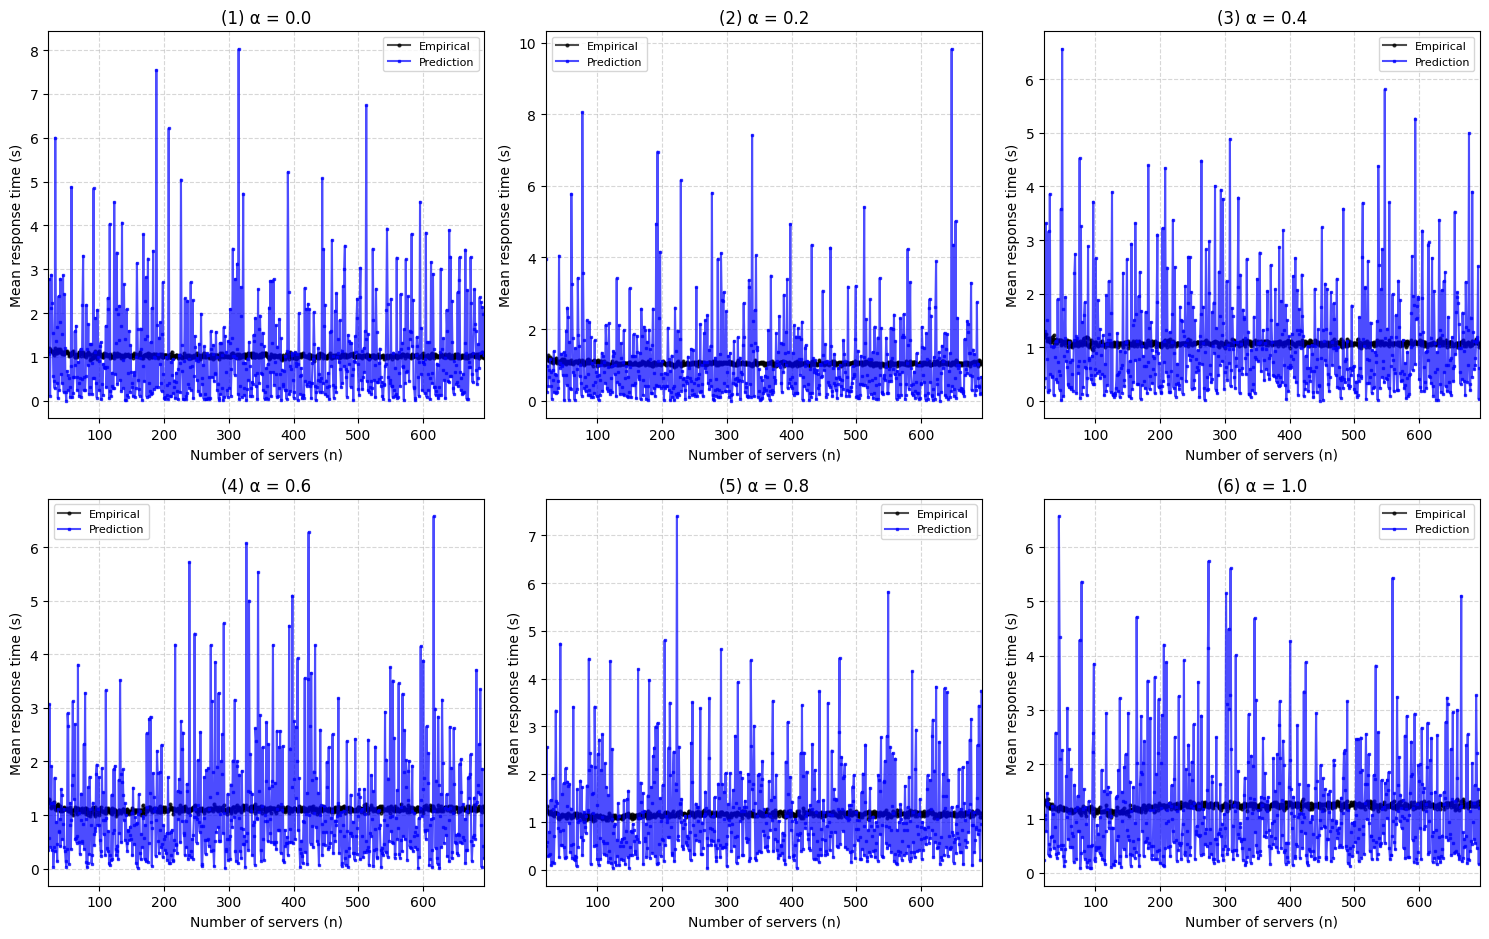

In [15]:
# Assuming state_df and investigate_df are already defined
fig, metrics = plot_all_alphas(experiment_data_df, mu_d=mu1, lam=LAMBDA, n_min=21, n_max=694)
plt.show()

# Save locally 
fig.savefig('naive_mu_prediction.png', dpi=300, bbox_inches='tight')

In [16]:
import heapq
import numpy as np

def process_group(group):
    """
    Process one run group (DataFrame) and compute the state i for each request.
    Returns a list of tuples: (n, alpha, i, client_measured_time, server_processing_time_measured).
    """
    # Extract n and alpha from the group (they are constant within a group)
    n = group['active_servers_num'].iloc[0]
    alpha = group['alpha'].iloc[0]
    
    # Sort by request_id to ensure chronological order
    group = group.sort_values('request_id').reset_index(drop=True)
    
    # Convert relevant columns to numpy arrays for speed
    time_until_next = group['time_untill_next_client'].values
    client_measured = group['client_measured_time'].values
    server_processing = group['server_processing_time_measured'].values
    
    # Compute arrival times: first at t=0, then cumulative sum of inter-arrival times
    arrival_times = np.zeros(len(group))
    if len(group) > 1:
        arrival_times[1:] = np.cumsum(time_until_next[:-1])
    
    # Departure times = arrival + total round‑trip time
    departure_times = arrival_times + client_measured
    
    # Min‑heap to track active departures (maintains earliest departure at top)
    heap = []
    states = []
    
    for k, t_arr in enumerate(arrival_times):
        # Remove all departures that happened before or at this arrival
        while heap and heap[0] <= t_arr:
            heapq.heappop(heap)
        
        # Number of active previous requests = heap size
        active_before = len(heap)
        i = active_before + 1   # total in system after this request joins
        
        # Store the state information
        states.append((n, alpha, i, client_measured[k], server_processing[k]))
        
        # Push current departure time into the heap for future arrivals
        heapq.heappush(heap, departure_times[k])
    
    return states

In [17]:
all_states = []
for (alpha, n, run), group in experiment_data_df.groupby(['alpha', 'active_servers_num', 'run_id']):
    all_states.extend(process_group(group))

# Convert to DataFrame
state_df = pd.DataFrame(all_states, columns=['n', 'alpha', 'i', 'client_measured_time', 'server_processing_time_measured'])

In [18]:
all_states[0]

(np.int64(21), np.float64(0.0), 1, np.float64(0.68), np.float64(0.674295))

In [19]:
# --- Aggregate by (n, alpha, i) to get mean times and counts ---
agg = state_df.groupby(['n', 'alpha', 'i']).agg(
    T_emp=('client_measured_time', 'mean'),
    S_emp=('server_processing_time_measured', 'mean'),
    count=('client_measured_time', 'size')
).reset_index()

In [20]:
# --- Calculate effective μ and pure μ ---
results = []

for _, row in agg.iterrows():
    n = int(row['n'])
    alpha = row['alpha']
    i = int(row['i'])
    T_emp = row['T_emp']
    S_emp = row['S_emp']
    count = row['count']
    
    # Pure service rate (from server processing time)
    mu_pure = 1.0 / S_emp if S_emp > 0 else np.nan
    
    # Effective service rate (from total round time)
    if i <= n:
        # No queue: T_emp = 1 / mu_eff
        mu_eff = 1.0 / T_emp if T_emp > 0 else np.nan
    else:
        # Queue: T_emp = i / (n * mu_eff)   (corrected formula)
        mu_eff = i / (n * T_emp) if T_emp > 0 else np.nan
    
    service_time_eff = 1.0 / mu_eff if not np.isnan(mu_eff) else np.nan
    service_time_pure = 1.0 / mu_pure if not np.isnan(mu_pure) else np.nan
    overhead = service_time_eff - service_time_pure if not np.isnan(service_time_eff) and not np.isnan(service_time_pure) else np.nan
    
    results.append({
        'n': n,
        'alpha': alpha,
        'i': i,
        'count': count,
        'mu_pure': mu_pure,
        'mu_eff': mu_eff,
        'service_time_pure (s)': service_time_pure,
        'service_time_eff (s)': service_time_eff,
        'overhead_per_request (s)': overhead
    })

results_df = pd.DataFrame(results)

## Use differnent methods to estimate via M/M/n model

In [21]:
%%time
from scipy.optimize import brentq
import numpy as np
from multiprocessing import Pool, cpu_count
import pandas as pd
import pickle

def _worker_n(n, df_subset, lam, mu_bounds, fallback):
    """Process all rows for a single n, return mu_dict for that n."""
    mu_low = max(mu_bounds[0], lam / n * 1.001)
    mu_high = mu_bounds[1]
    T_low = T_mmn(mu_low, lam, n)
    T_high = T_mmn(mu_high, lam, n)
    
    local_dict = {}
    for _, row in df_subset.iterrows():  # can use itertuples for speed
        alpha = row['alpha']
        T_target = row['client_measured_time']
        f_low = T_low - T_target
        f_high = T_high - T_target
        
        if np.isinf(f_low) or np.isinf(f_high) or f_low * f_high >= 0:
            local_dict[(n, alpha)] = fallback.get((n, alpha), np.nan)
        else:
            try:
                mu = brentq(lambda mu: T_mmn(mu, lam, n) - T_target, mu_low, mu_high)
                local_dict[(n, alpha)] = mu
            except Exception:
                local_dict[(n, alpha)] = fallback.get((n, alpha), np.nan)
    return local_dict

def estimate_mu_n_alpha_2_parallel(investigate_df, lam=0.3, mu_bounds=(0.01, 20.0), n_workers=None):
    """
    Parallel version of estimate_mu_n_alpha_2.
    Splits work by unique n and processes each in a separate process.
    """
    fallback = estimate_mu_n_alpha_1(investigate_df)
    
    # Group by n to create chunks
    grouped = investigate_df.groupby('active_servers_num')
    n_groups = [(n, group) for n, group in grouped]
    
    if n_workers is None:
        n_workers = cpu_count()
    
    with Pool(processes=n_workers) as pool:
        # Prepare arguments for each chunk: (n, df_subset, lam, mu_bounds, fallback)
        args = [(n, df, lam, mu_bounds, fallback) for n, df in n_groups]
        results = pool.starmap(_worker_n, args)
    
    # Merge dictionaries
    mu_dict = {}
    for d in results:
        mu_dict.update(d)
    return mu_dict

"""
The function estimate_mu_n_alpha_2 implements calibration of a single constant service rate μ(n,α)
    for each configuration (n,α) by inverting the standard M/M/n (Erlang‑C) formula. 
The goal is to find a service rate such that the theoretical mean response time exactly matches the 
    empirically observed mean total round time Temp (from client_measured_time). 
This is a widely used technique in queueing theory when one wants to "reverse‑engineer" the service rate 
    from observed performance, under the assumption that the system behaves like an M/M/n queue.
"""
cache_file_mu2 = "mu2.pkl"
try:
    with open(cache_file_mu2, 'rb') as fp:
        mu2 = pickle.load(fp)
except:
    mu2 = estimate_mu_n_alpha_2_parallel(experiment_data_df, lam=LAMBDA, n_workers=10)
    with open(cache_file_mu2, 'wb') as fp:
        pickle.dump(mu2, fp)

CPU times: user 220 μs, sys: 970 μs, total: 1.19 ms
Wall time: 1.11 ms



MODEL PERFORMANCE METRICS PER α
           RMSE     MAE     MAPE
0.0      1.1047  0.7842  76.0845
0.2      1.1521  0.7895  75.4298
0.4      0.9805  0.7233  67.2174
0.6      1.0239  0.7477  67.4347
0.8      0.9482  0.7040  61.0170
1.0      1.0172  0.7706  63.0047
Average  1.0378  0.7532  68.3647
Average RMSE: 1.0378  |  Average MAE: 0.7532  |  Average MAPE: 68.3647%


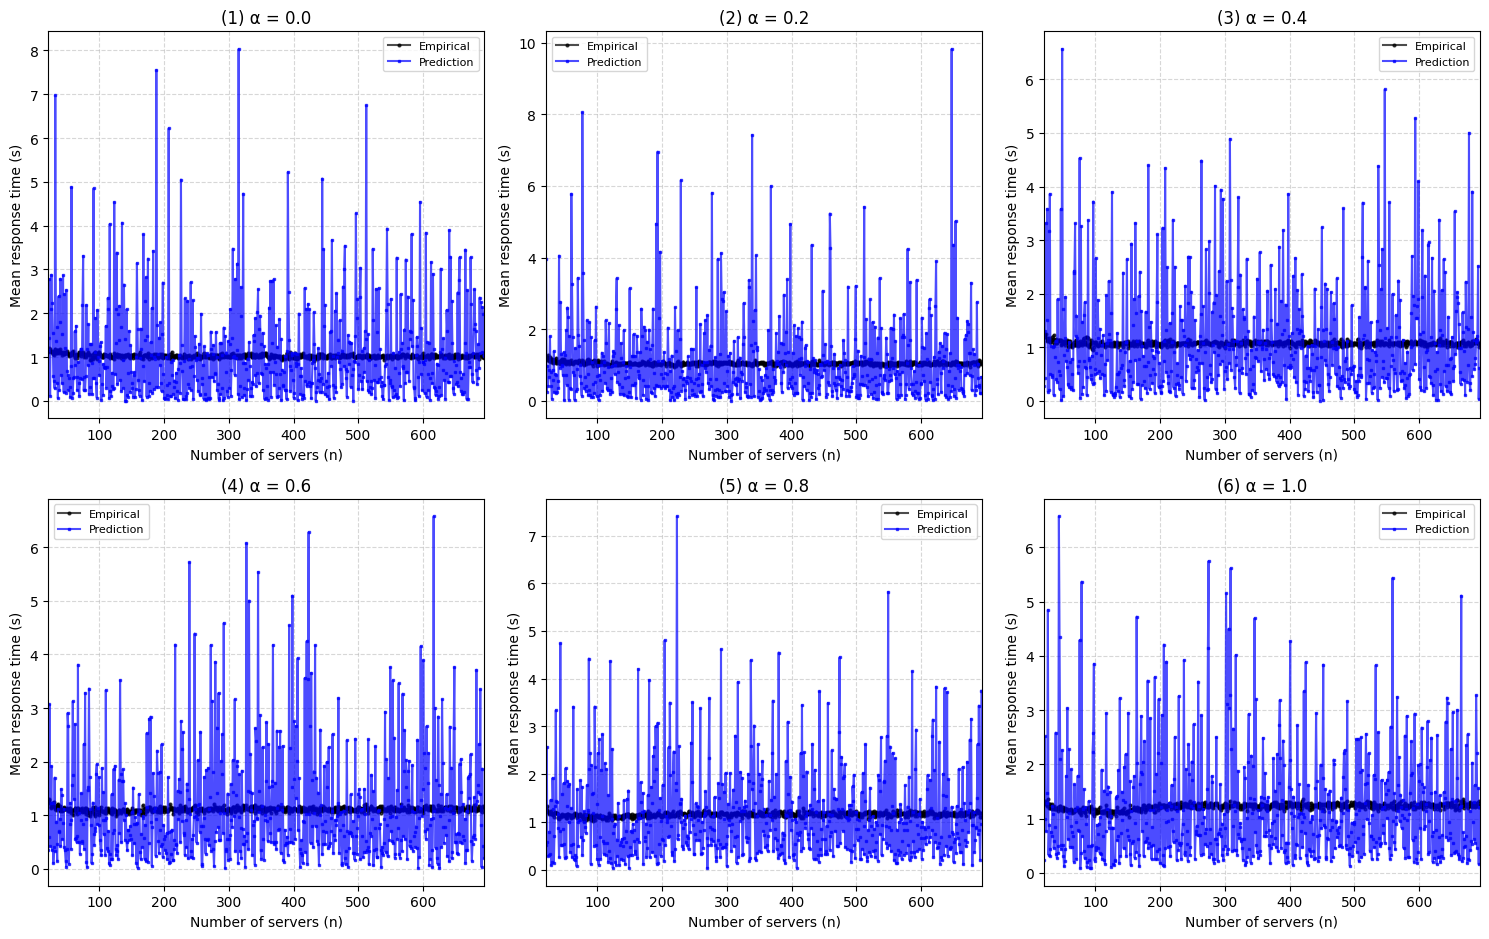


MODEL PERFORMANCE METRICS PER α
           RMSE     MAE     MAPE
0.0      1.1047  0.7842  76.0845
0.2      1.1521  0.7895  75.4298
0.4      0.9805  0.7233  67.2174
0.6      1.0239  0.7477  67.4347
0.8      0.9482  0.7040  61.0170
1.0      1.0172  0.7706  63.0047
Average  1.0378  0.7532  68.3647
Average RMSE: 1.0378  |  Average MAE: 0.7532  |  Average MAPE: 68.3647%


In [22]:
# Assuming state_df and investigate_df are already defined
fig, metrics = plot_all_alphas(experiment_data_df, mu_d=mu2, lam=LAMBDA, n_min=21, n_max=694)
plt.show()
# Optionally save
# fig.savefig('comparison_all_alphas.png', dpi=300, bbox_inches='tight')

print_metrics_table(metrics, decimals=4)

In [23]:
def estimate_mu_low_load(state_df):
    """
    Compute μ(n, α) from the mean client_measured_time for requests
    that experienced no queue (i < n).

    Parameters
    ----------
    state_df : pd.DataFrame
        Per‑request DataFrame with columns: n, alpha, i, client_measured_time.
        Must contain the state i for each request.

    Returns
    -------
    dict
        Keys: (n, alpha)  →  value: service rate = 1 / mean(total_time).
    """
    low_load = state_df[state_df['i'] < state_df['n']]
    # Compute mean total time per (n, alpha)
    mean_times = low_load.groupby(['n', 'alpha'])['mu_eff'].mean()
    # Invert to get service rate
    mu_dict = {(n, alpha): t for (n, alpha), t in mean_times.items() if t > 0}
    return mu_dict


MODEL PERFORMANCE METRICS PER α
           RMSE     MAE     MAPE
0.0      0.2318  0.1459  14.1781
0.2      0.1937  0.1231  11.7818
0.4      0.1972  0.1251  11.6587
0.6      0.1676  0.1103   9.9710
0.8      0.1372  0.0921   8.0103
1.0      0.1080  0.0767   6.2791
Average  0.1726  0.1122  10.3131
Average RMSE: 0.1726  |  Average MAE: 0.1122  |  Average MAPE: 10.3131%


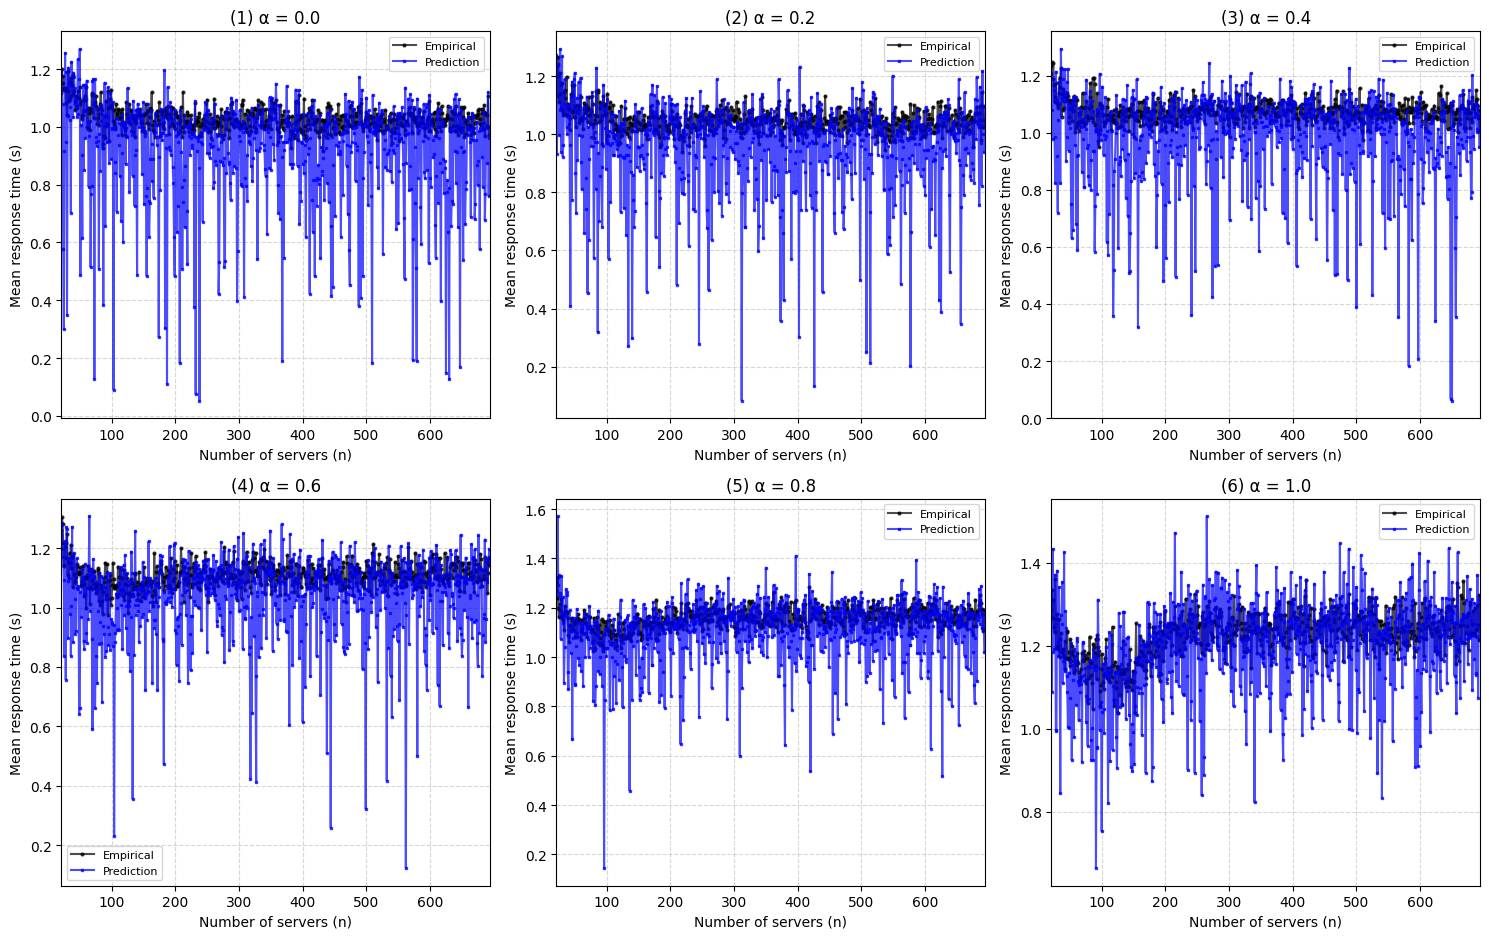


MODEL PERFORMANCE METRICS PER α
           RMSE     MAE     MAPE
0.0      0.2318  0.1459  14.1781
0.2      0.1937  0.1231  11.7818
0.4      0.1972  0.1251  11.6587
0.6      0.1676  0.1103   9.9710
0.8      0.1372  0.0921   8.0103
1.0      0.1080  0.0767   6.2791
Average  0.1726  0.1122  10.3131
Average RMSE: 0.1726  |  Average MAE: 0.1122  |  Average MAPE: 10.3131%


In [24]:
mu_low = estimate_mu_low_load(results_df)
fig, metrics = plot_all_alphas(experiment_data_df, mu_d=mu_low, lam=LAMBDA, n_min=21, n_max=694)
plt.show()

print_metrics_table(metrics, decimals=4)

## "mu_n_alpha_i" and "mu_n_alpha" creation

In [25]:
mean_T_dict = state_df.groupby(['n', 'alpha'])['client_measured_time'].mean().to_dict()
mu_n_alpha = {k:(1/v) for k, v in mean_T_dict.items()}

In [26]:
# --- Output the dictionary mu_n_alpha_i for your model ---
mu_n_alpha_i = {}
filter_df = results_df['count'] > 30
for _, row in results_df[filter_df].iterrows():
    key = (row['n'], row['alpha'], row['i'])
    mu_n_alpha_i[key] = row['mu_eff']

In [27]:
mu_n_alpha2 = {}
filter_df = results_df['count'] > 30
for (n, alpha), group in results_df[filter_df].groupby(['n', 'alpha']):
    mu_n_alpha2[(n, alpha)] =  group['mu_eff'].mean()

In [28]:
mu_n_alpha3 = {}
for (alpha, n), group in experiment_data_df.groupby(['alpha', 'active_servers_num']):
    mu_n_alpha3[(n, alpha)] = 1 / group['client_measured_time'].mean()

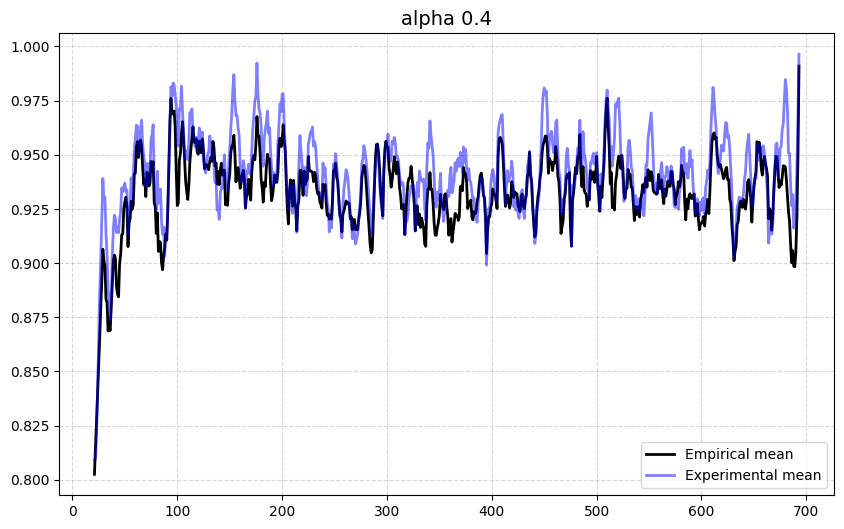

'RMSE: 0.0224 | MAE: 0.0173 | MAPE: 1.8612%'

In [29]:
alpha = 0.4
n_range = range(21, 694)

fig, ax = plt.subplots(figsize=(10, 6))

emp_mean1 = []
emp_mean2 = []
for n in n_range:
    # Empirical mean
    emp_mean1.append(mu_n_alpha[(n, alpha)])
    # Prediction
    emp_mean2.append(mu_n_alpha2[(n, alpha)])

df_alpha = state_df[state_df['alpha'] == alpha]
total_round_time_n_alpha = df_alpha.groupby('n')['client_measured_time'].mean()

y_smooth1 = savgol_filter(emp_mean1, window_length, polyorder)
y_smooth2 = savgol_filter(emp_mean2, window_length, polyorder)
ax.plot(n_range, y_smooth1, 'k-', label='Empirical mean', markersize=5, linewidth=2)
ax.plot(n_range, y_smooth2, 'b-', label='Experimental mean', markersize=5, linewidth=2, alpha=0.5)

ax.set_title(f"alpha {alpha}", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=10)
plt.show()

metrics = compare_results(emp_mean1, emp_mean2)
format_comparison(metrics)

In [30]:
# Helper to retrieve μ for a given state n, alpha, i.
def make_mu_getter(mu_n_alpha_i, fallback_mu_n_alpha=None):
    """
    Создаёт функцию для получения μ(n, α, i) с возможностью резервного словаря.

    Параметры
    ----------
    mu_n_alpha_i : dict
        Словарь с ключами (n, alpha, i) -> μ.
    fallback_mu_n_alpha : dict, optional
        Резервный словарь с ключами (n, alpha) -> μ.

    Возвращает
    ----------
    function
        Функция get_mu(n, alpha, i) -> μ.
        Если ключ отсутствует, выбрасывает ValueError.
    """
    def get_mu(n, alpha, i):
        key = (n, alpha, i)
        if key in mu_n_alpha_i:
            return mu_n_alpha_i[key]
        if fallback_mu_n_alpha is not None and type(fallback_mu_n_alpha) is dict:
            fb_key = (n, alpha)
            if fb_key in fallback_mu_n_alpha:
                return fallback_mu_n_alpha[fb_key]
        raise ValueError(f"Missing μ for n={n}, alpha={alpha}, i={i}")
    return get_mu

In [31]:
def predict_T(n, alpha, lam, get_mu):
    """
    Predict the mean total round time T for an M/M/n queue with state‑dependent
    service rates μ(n, α, i).  This function implements your exact formulas
    using numerically stable recurrences.

    Parameters
    ----------
    n : int
        Number of servers (containers).
    alpha : float
        The proportion of CPU‑bound requests.
    lam : float
        Arrival rate (λ).
    mu_n_alpha_i : dict
        Dictionary with keys (n, alpha, i) mapping to the effective service
        rate μ(n, α, i).  Must contain rates for i = 1 .. n, unless a fallback
        is provided.
    fallback_mu_n_alpha : dict, optional
        Dictionary with keys (n, alpha) mapping to a single constant service rate
        μ(n, α).  Used for any state i that is missing from mu_n_alpha_i.

    Returns
    -------
    T : float
        Mean response time (sojourn time) in the system, in seconds.

    Raises
    ------
    ValueError
        If a required μ cannot be found and no fallback is available, or if the
        system is unstable (n·μ(n,α,n) - λ ≤ 0).
    """
    # Retrieve all required rates for i = 1 .. n
    mu_vals = [get_mu(n, alpha, i) for i in range(1, n+1)]

    # ------------------------------------------------------------------
    # 1.  Compute A_k = λ^k / ( k! * Π_{j=1}^k μ_j )  for k = 0..n
    #     using recurrence: A_0 = 1, A_k = A_{k-1} * λ / (k * μ_k)
    # ------------------------------------------------------------------
    A = 1.0               # A_0
    sum1 = 0.0            # Σ_{k=1}^{n} A_k
    sum_L1 = 0.0          # Σ_{k=1}^{n} k * A_k   (needed for L)

    for k in range(1, n+1):
        mu_k = mu_vals[k-1]
        A = A * lam / (k * mu_k)   # now A = A_k
        sum1 += A
        sum_L1 += k * A

    # After the loop, A == A_n
    A_n = A
    mu_n = mu_vals[n-1]   # μ(n, α, n)

    # ------------------------------------------------------------------
    # 2.  Stability condition: n * μ_n - λ must be > 0
    # ------------------------------------------------------------------
    denom = n * mu_n - lam
    if denom <= 0:
        raise ValueError(
            f"Unstable for n={n}, α={alpha}: n·μ_n - λ = {denom} ≤ 0. "
            "Increase servers or reduce load."
        )

    # ------------------------------------------------------------------
    # 3.  Compute p0 using the recurrence‑based expressions.
    #     The term for k = n+1 is  λ^(n+1) / ( n! * prod_n * (n μ_n - λ) )
    #     but λ^(n+1) / (n! * prod_n) = A_n * λ, so:
    # ------------------------------------------------------------------
    term_n1 = A_n * lam / denom
    p0 = 1.0 / (1.0 + sum1 + term_n1)

    # ------------------------------------------------------------------
    # 4.  Compute L (mean number in system) using the second part of your formula.
    #     L = [ Σ_{k=1}^n k A_k  +  extra ] * p0
    #     where extra =  λ^(n+1) / ((n-1)! prod_n) *
    #                    (1 + μ_n/(n μ_n - λ)) / (n μ_n - λ)
    #
    #     But λ^(n+1) / ((n-1)! prod_n) = n * λ * A_n, so:
    # ------------------------------------------------------------------
    factor = n * lam * A_n / denom
    term_L2 = factor * (1.0 + mu_n / denom)

    L = (sum_L1 + term_L2) * p0

    # ------------------------------------------------------------------
    # 5.  Little's Law: T = L / λ
    # ------------------------------------------------------------------
    T = L / lam
    return T

In [32]:
%%time

import numpy as np
from multiprocessing import Pool, cpu_count
from functools import partial

def compute_metrics_for_threshold(min_count, results_df, experiment_data_df, n_range, lamb):
    # 1. Filter states with count > min_count
    mask = results_df['count'] > min_count
    filtered = results_df[mask]
    mu_n_alpha_i = {
        (row['n'], row['alpha'], row['i']): row['mu_eff']
        for _, row in filtered.iterrows()
    }

    # 2. Pre‑compute empirical means once per alpha
    emp_means = experiment_data_df.groupby(['alpha', 'active_servers_num'])['client_measured_time'].mean()

    # 3. For each alpha, compute predictions
    metrics = {}
    for alpha in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        T_pred = []
        for n in n_range:
            T = predict_T(n=n, alpha=alpha, lam=lamb,
                          get_mu=make_mu_getter(
                              mu_n_alpha_i=mu_n_alpha_i, 
                              fallback_mu_n_alpha=mu_n_alpha2
                          )
                )
            T_pred.append(T)
        
        # Align true values
        y_true = [emp_means.loc[(alpha, n)] for n in n_range]
        rmse, mae, mape = compare_results(y_true, T_pred)
        metrics[alpha] = (rmse, mae, mape)
    
    return min_count, metrics

# Calculate results_d
n_range = list(range(21, 694))
lamb = LAMBDA  # your constant

thresholds = range(0, 100)
# Use multiprocessing to speed up
with Pool(processes=cpu_count()) as pool:
    partial_func = partial(
        compute_metrics_for_threshold,
        results_df=results_df,
        experiment_data_df=experiment_data_df,
        n_range=n_range,
        lamb=lamb
    )
    all_results = pool.map(partial_func, thresholds)

# Combine results into a dict: results_d[(min_count, alpha)] = (rmse, mae, mape)
results_d = {}
for min_count, alpha_metrics in all_results:
    for alpha, metrics_tuple in alpha_metrics.items():
        results_d[(min_count, alpha)] = metrics_tuple

CPU times: user 3.1 s, sys: 13.6 s, total: 16.7 s
Wall time: 32.5 s


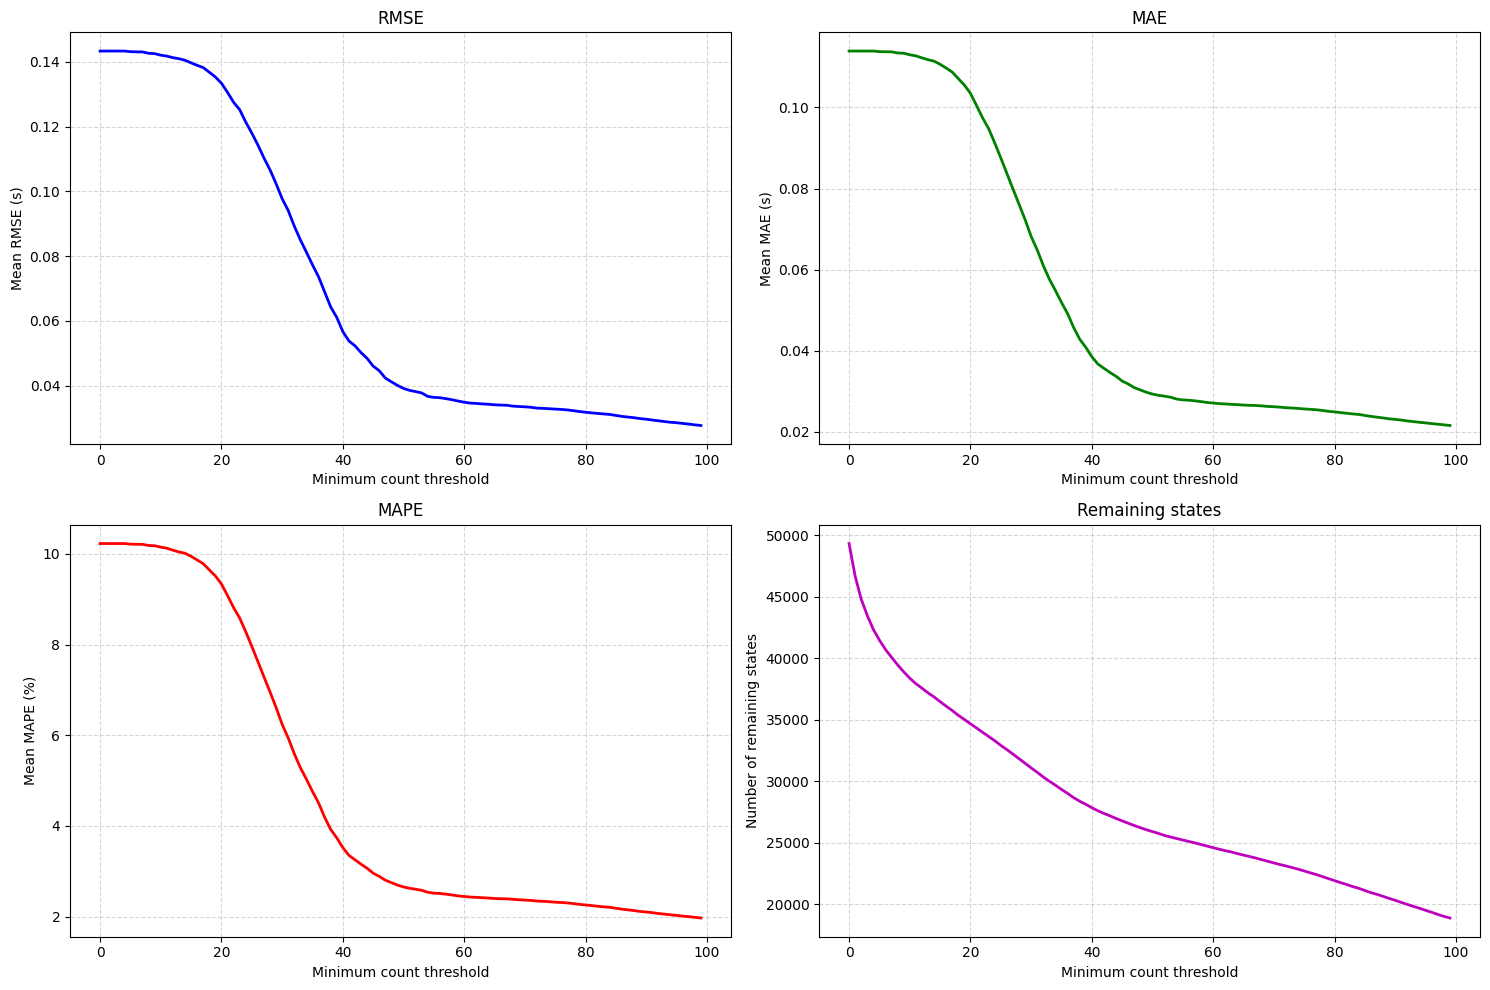

In [33]:
def plot_metrics_vs_mincount(results_d, results_df, save_path=None, figsize=(15, 10)):
    """
    Plot the mean (across alphas) of RMSE, MAE, and MAPE against min_count,
    and also plot the number of remaining states (tuples) after filtering.

    Parameters
    ----------
    results_d : dict
        Dictionary with keys (min_count, alpha) and values (rmse, mae, mape).
    results_df : pd.DataFrame
        Contains columns: count, n, alpha, i (or similar) to compute remaining states.
    save_path : str, optional
        If provided, saves the figure to this path.
    figsize : tuple, optional
        Figure size (width, height).

    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated figure.
    """
    # Convert results_d to DataFrame for metrics
    data = []
    for (min_count, alpha), (rmse, mae, mape) in results_d.items():
        data.append({
            'min_count': min_count,
            'alpha': alpha,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape
        })
    df_metrics = pd.DataFrame(data)
    
    # Group by min_count and compute mean across alphas
    grouped = df_metrics.groupby('min_count').agg({
        'RMSE': 'mean',
        'MAE': 'mean',
        'MAPE': 'mean'
    }).reset_index()
    
    # Compute number of remaining states per min_count
    # We assume results_df has column 'count' and we consider each row as a state
    remaining_counts = []
    thresholds = sorted(grouped['min_count'].unique())
    for threshold in thresholds:
        # Count rows with count > threshold
        n_remaining = (results_df['count'] > threshold).sum()
        remaining_counts.append(n_remaining)
    
    # Create 2x2 subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    # RMSE
    axes[0, 0].plot(grouped['min_count'], grouped['RMSE'], 'b-', linewidth=2)
    axes[0, 0].set_xlabel('Minimum count threshold')
    axes[0, 0].set_ylabel('Mean RMSE (s)')
    axes[0, 0].grid(True, linestyle='--', alpha=0.5)
    axes[0, 0].set_title('RMSE')
    
    # MAE
    axes[0, 1].plot(grouped['min_count'], grouped['MAE'], 'g-', linewidth=2)
    axes[0, 1].set_xlabel('Minimum count threshold')
    axes[0, 1].set_ylabel('Mean MAE (s)')
    axes[0, 1].grid(True, linestyle='--', alpha=0.5)
    axes[0, 1].set_title('MAE')
    
    # MAPE
    axes[1, 0].plot(grouped['min_count'], grouped['MAPE'], 'r-', linewidth=2)
    axes[1, 0].set_xlabel('Minimum count threshold')
    axes[1, 0].set_ylabel('Mean MAPE (%)')
    axes[1, 0].grid(True, linestyle='--', alpha=0.5)
    axes[1, 0].set_title('MAPE')
    
    # Remaining states count
    axes[1, 1].plot(thresholds, remaining_counts, 'm-', linewidth=2)
    axes[1, 1].set_xlabel('Minimum count threshold')
    axes[1, 1].set_ylabel('Number of remaining states')
    axes[1, 1].grid(True, linestyle='--', alpha=0.5)
    axes[1, 1].set_title('Remaining states')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig

fig = plot_metrics_vs_mincount(results_d, results_df=results_df, save_path="average_performance_metrics_vs_minimum_sample_count.png")

In [34]:
from scipy import stats

def plot_threshold_grid(
    results_df,          # contains columns: n, alpha, i, count, mu_eff
    experiment_data_df,  # raw data for empirical means (client_measured_time)
    state_df,            # per‑request data for confidence intervals (n, alpha, client_measured_time)
    fallback_mu,         # dict (n, alpha) -> service rate for fallback
    alpha=0.4,
    lam=0.3,
    thresholds=[0, 20, 40, 60, 80, 100],
    n_range=None,
    figsize=(15, 10),
    confidence_level=0.95
):
    # 1. Compute empirical confidence intervals (same for all subplots)
    df_alpha = state_df[state_df['alpha'] == alpha]
    emp_stats = df_alpha.groupby('n')['client_measured_time'].agg(
        mean='mean',
        std='std',
        count='size'
    ).reset_index()
    t_val = stats.t.ppf(1 - (1 - confidence_level)/2, emp_stats['count'] - 1)
    emp_stats['sem'] = emp_stats['std'] / np.sqrt(emp_stats['count'])
    emp_stats['ci_lower'] = emp_stats['mean'] - t_val * emp_stats['sem']
    emp_stats['ci_upper'] = emp_stats['mean'] + t_val * emp_stats['sem']
    emp_stats = emp_stats.sort_values('n')
    emp_n = emp_stats['n'].values
    emp_mean = emp_stats['mean'].values
    emp_lower = emp_stats['ci_lower'].values
    emp_upper = emp_stats['ci_upper'].values

    if n_range is None:
        n_range = sorted(emp_n)

    # Pre‑compute empirical means per (n, alpha)
    emp_means_full = experiment_data_df.groupby(['alpha', 'active_servers_num'])['client_measured_time'].mean()

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    all_metrics = []

    for idx, threshold in enumerate(thresholds):
        ax = axes[idx]

        # Filter states with count > threshold
        mask = results_df['count'] > threshold
        filtered = results_df[mask]
        mu_n_alpha_i = {
            (row['n'], row['alpha'], row['i']): row['mu_eff']
            for _, row in filtered.iterrows()
        }

        # Compute predictions
        T_pred = []
        for n in n_range:
            T = predict_T(
                n=n,
                alpha=alpha,
                lam=lam,
                get_mu=make_mu_getter(
                              mu_n_alpha_i=mu_n_alpha_i, 
                              fallback_mu_n_alpha=fallback_mu
                )
            )
            T_pred.append(T)

        y_true = [emp_means_full.loc[(alpha, n)] for n in n_range]
        y_pred = T_pred

        # Compute metrics
        try:
            rmse, mae, mape = compare_results(y_true, y_pred)
            all_metrics.append((threshold, rmse, mae, mape))
            
            metrics_str = format_comparison((rmse, mae, mape), decimals=4)
            print(f'min_count > {threshold} | {metrics_str}')
        except Exception as e:
            metrics_str = f"Metrics error: {e}"

        # Plot
        ax.plot(emp_n, emp_mean, 'ko-', label='Empirical mean', markersize=2, linewidth=1.5)
        ax.fill_between(emp_n, emp_lower, emp_upper, color='gray', alpha=0.3,
                        label=f'{int(confidence_level*100)}% CI')
        
        
        T_pred_smooth = savgol_filter(T_pred, window_length, polyorder)
        # ax.plot(n_range, T_pred_smooth, 'b-s', label=f'Prediction (min_count>{threshold})',
        ax.plot(n_range, T_pred, 'b-s', label=f'Prediction (min_count>{threshold})',
                markersize=2, linewidth=1.5, alpha=0.6)

        ax.set_xlabel('Number of servers (n)')
        ax.set_ylabel('Mean response time (s)')
        ax.set_title(f'min_count > {threshold}')
        ax.grid(True, linestyle='--', alpha=0.5)

        # Legend placed at bottom center
        ax.legend(fontsize=8, loc='lower center')

        # Metrics text box (still at top-left)
        ax.text(0.02, 0.98, metrics_str, transform=ax.transAxes,
                verticalalignment='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

min_count > 0 | RMSE: 0.1250 | MAE: 0.0991 | MAPE: 9.6007%
min_count > 20 | RMSE: 0.1194 | MAE: 0.0941 | MAPE: 9.1317%
min_count > 40 | RMSE: 0.0631 | MAE: 0.0432 | MAPE: 4.2253%
min_count > 60 | RMSE: 0.0334 | MAE: 0.0246 | MAPE: 2.3818%
min_count > 80 | RMSE: 0.0286 | MAE: 0.0227 | MAPE: 2.1960%
min_count > 100 | RMSE: 0.0274 | MAE: 0.0217 | MAPE: 2.1022%


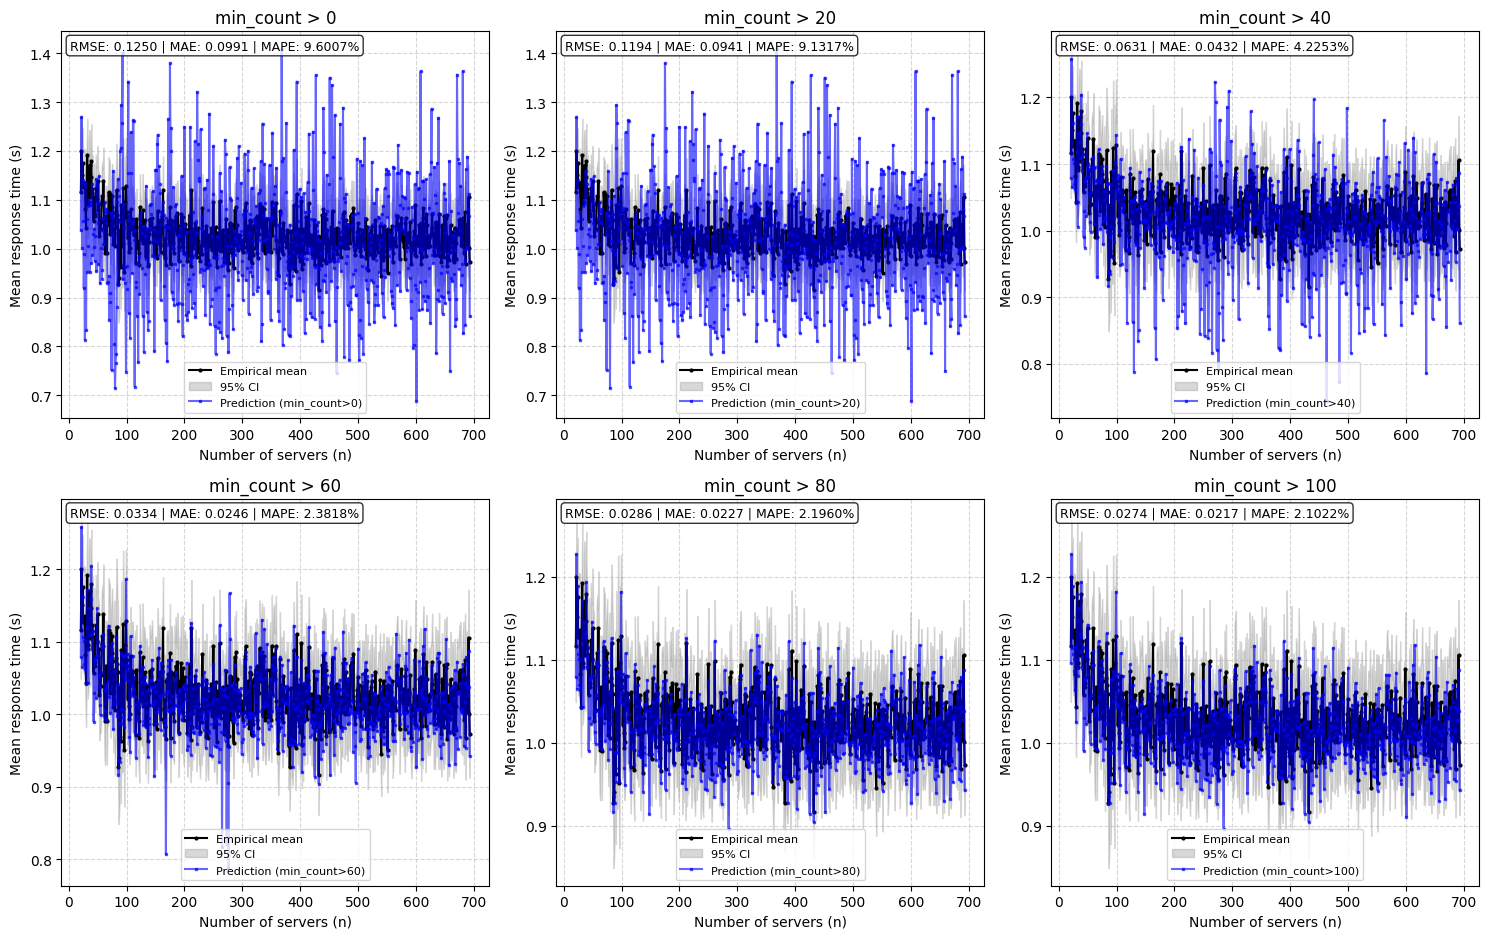

In [35]:
fig = plot_threshold_grid(
    results_df=results_df,        
    experiment_data_df=experiment_data_df,
    state_df=state_df,
    fallback_mu=mu_n_alpha2,      
    alpha=0.0,
    lam=LAMBDA,
    thresholds=[0, 20, 40, 60, 80, 100],
    n_range=list(range(21, 694))
)
plt.show()

min_count > 0 | RMSE: 0.1367 | MAE: 0.1075 | MAPE: 9.9726%
min_count > 20 | RMSE: 0.1291 | MAE: 0.1005 | MAPE: 9.3423%
min_count > 40 | RMSE: 0.0573 | MAE: 0.0378 | MAPE: 3.5242%
min_count > 60 | RMSE: 0.0316 | MAE: 0.0246 | MAPE: 2.2882%
min_count > 80 | RMSE: 0.0304 | MAE: 0.0239 | MAPE: 2.2203%
min_count > 100 | RMSE: 0.0270 | MAE: 0.0213 | MAPE: 1.9805%


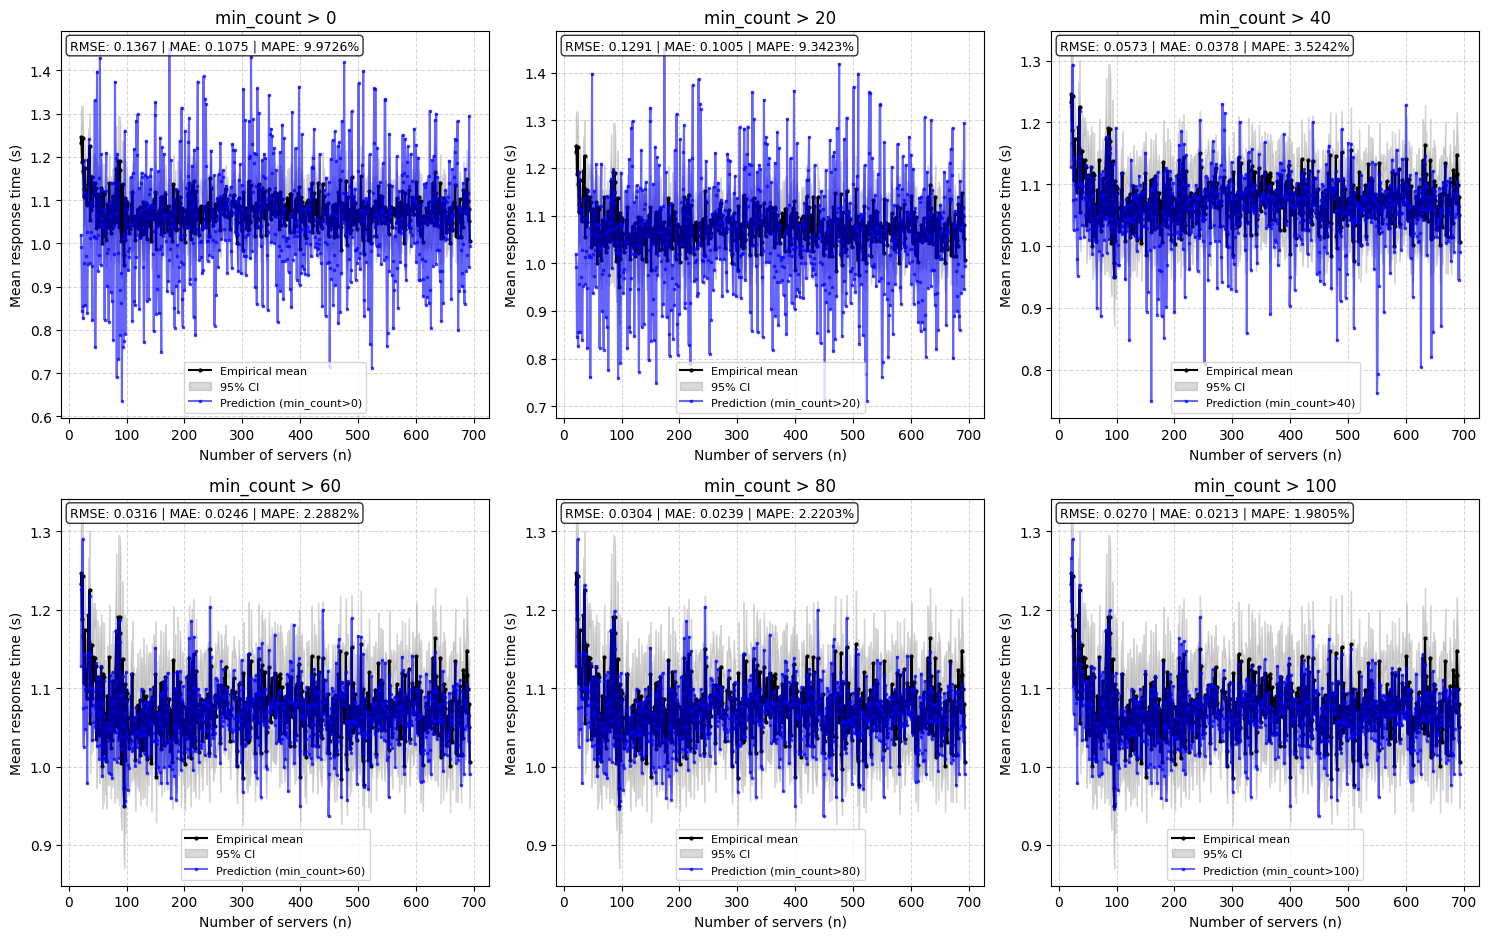

In [36]:
fig = plot_threshold_grid(
    results_df=results_df,        
    experiment_data_df=experiment_data_df,
    state_df=state_df,
    fallback_mu=mu_n_alpha2,      
    alpha=0.4,
    lam=LAMBDA,
    thresholds=[0, 20, 40, 60, 80, 100],
    n_range=list(range(21, 694))
)
plt.show()

min_count > 0 | RMSE: 0.1740 | MAE: 0.1417 | MAPE: 11.5353%
min_count > 20 | RMSE: 0.1546 | MAE: 0.1181 | MAPE: 9.6327%
min_count > 40 | RMSE: 0.0536 | MAE: 0.0374 | MAPE: 3.0579%
min_count > 60 | RMSE: 0.0414 | MAE: 0.0320 | MAPE: 2.6091%
min_count > 80 | RMSE: 0.0340 | MAE: 0.0258 | MAPE: 2.1120%
min_count > 100 | RMSE: 0.0259 | MAE: 0.0197 | MAPE: 1.6164%


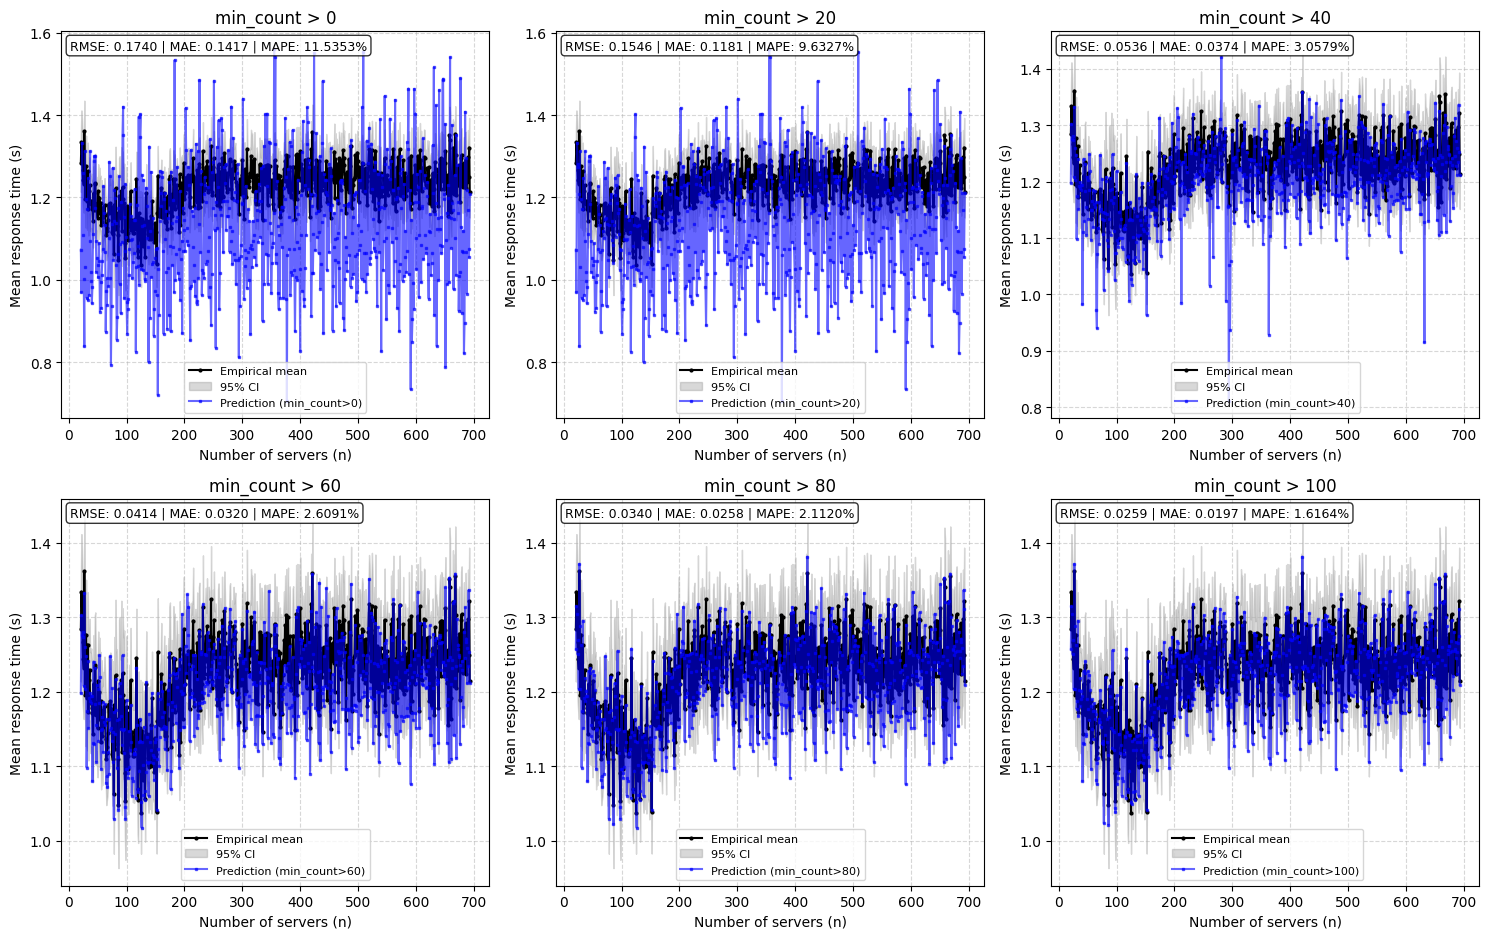

In [37]:
fig = plot_threshold_grid(
    results_df=results_df,        
    experiment_data_df=experiment_data_df,
    state_df=state_df,
    fallback_mu=mu_n_alpha2,      
    alpha=1.0,
    lam=LAMBDA,
    thresholds=[0, 20, 40, 60, 80, 100],
    n_range=list(range(21, 694))
)
plt.show()

## Train models to predict mu

In [38]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [39]:
def split_train_test_by_run(received_results_df, train_ratio=0.8, random_state=42):
    unique_runs = received_results_df['run_id'].unique()
    train_runs, test_runs = train_test_split(
        unique_runs, train_size=train_ratio, random_state=random_state
    )
    train_df = received_results_df[received_results_df['run_id'].isin(train_runs)]
    test_df = received_results_df[received_results_df['run_id'].isin(test_runs)]
    return train_df, test_df

In [40]:
def process_runs_for_state(df):
    all_states = []
    for (alpha, n, run), group in df.groupby(['alpha', 'active_servers_num', 'run_id']):
        all_states.extend(process_group(group))
    state_df = pd.DataFrame(all_states, columns=['n', 'alpha', 'i', 'client_measured_time', 'server_processing_time_measured'])
    return state_df

def build_training_dictionaries(train_df, lam=0.3, min_count_state=5, min_count_avg=30):
    # 1. Reconstruct states
    state_df = process_runs_for_state(train_df)
    
    # 2. Aggregate state-dependent effective rates (mu_eff) from client_measured_time
    agg = state_df.groupby(['n', 'alpha', 'i']).agg(
        T_emp=('client_measured_time', 'mean'),
        count=('client_measured_time', 'size')
    ).reset_index()
    
    # 2a. Build mu_d (state-dependent) with minimum count threshold
    agg_state = agg[agg['count'] >= min_count_state].copy()
    mu_d = {}
    for _, row in agg_state.iterrows():
        n = int(row['n'])
        alpha = row['alpha']
        i = int(row['i'])
        T_emp = row['T_emp']
        if T_emp > 0:
            if i <= n:
                mu_eff = 1.0 / T_emp
            else:
                mu_eff = i / (n * T_emp)
            mu_d[(n, alpha, i)] = mu_eff
    
    # 2b. Build mu1 (simple from server_processing_time_measured)
    mu1 = {}
    simple_agg = state_df.groupby(['n', 'alpha'])['server_processing_time_measured'].mean().reset_index()
    for _, row in simple_agg.iterrows():
        n = int(row['n'])
        alpha = row['alpha']
        s_mean = row['server_processing_time_measured']
        if s_mean > 0:
            mu1[(n, alpha)] = 1.0 / s_mean
    
    # 2c. Build mu_avg_eff: average of mu_eff across i for each (n, alpha), using only states with count > min_count_avg
    # We need to compute mu_eff for all states (even those below min_count_state) to get a representative average,
    # but we filter by count > min_count_avg to ensure reliability.
    # First, compute mu_eff for all states (without min_count_state filter)
    agg_all = agg.copy()
    def compute_mu_eff(row):
        n = int(row['n'])
        alpha = row['alpha']
        i = int(row['i'])
        T_emp = row['T_emp']
        if T_emp > 0:
            if i <= n:
                return 1.0 / T_emp
            else:
                return i / (n * T_emp)
        return np.nan
    agg_all['mu_eff'] = agg_all.apply(compute_mu_eff, axis=1)
    
    # Filter by count > min_count_avg
    avg_filter = agg_all['count'] > min_count_avg
    avg_group = agg_all[avg_filter].groupby(['n', 'alpha'])['mu_eff'].mean().reset_index()
    mu_avg_eff = {}
    for _, row in avg_group.iterrows():
        n = int(row['n'])
        alpha = row['alpha']
        mu_avg = row['mu_eff']
        if not np.isnan(mu_avg):
            mu_avg_eff[(n, alpha)] = mu_avg
    
    return mu_d, mu1, mu_avg_eff

In [41]:
def evaluate_test_data(test_df, mu_d, mu1, mu_avg_eff, lam=0.3):
    # 1. Reconstruct states for test data
    state_df_test = process_runs_for_state(test_df)
    
    # 2. Empirical mean T per (n, alpha)
    emp_means = state_df_test.groupby(['n', 'alpha'])['client_measured_time'].mean().reset_index()
    emp_means.rename(columns={'client_measured_time': 'T_emp'}, inplace=True)
    
    # 3. Define prediction functions
    def predict_T_state(n, alpha):
        return predict_T(n=n, alpha=alpha, lam=lamb,
                         get_mu=make_mu_getter(
                              mu_n_alpha_i=mu_d, 
                              fallback_mu_n_alpha=mu1
                ))
    
    def predict_T_simple_mu1(n, alpha):
        mu = mu1.get((n, alpha))
        if mu is not None and not np.isnan(mu):
            return T_mmn(mu, lam, n)
        return np.nan
    
    def predict_T_simple_mu_avg(n, alpha):
        return predict_T(n=n, alpha=alpha, lam=lamb,
                         get_mu=make_mu_getter(
                              mu_n_alpha_i=mu_d, 
                              fallback_mu_n_alpha=mu_avg_eff
                ))
    predictions = []
    for _, row in emp_means.iterrows():
        n = int(row['n'])
        alpha = row['alpha']
        T_emp = row['T_emp']
        
        # State-dependent
        try:
            T_pred_state = predict_T_state(n, alpha)
        except Exception:
            T_pred_state = np.nan
        
        # Simple with mu1
        T_pred_mu1 = predict_T_simple_mu1(n, alpha)
        
        # State-dependent with mu_avg_eff
        try:
            T_pred_mu_avg = predict_T_simple_mu_avg(n, alpha)
        except Exception:
            T_pred_mu_avg = np.nan
        
        
        predictions.append({
            'n': n,
            'alpha': alpha,
            'T_emp': T_emp,
            'T_pred_state': T_pred_state,
            'T_pred_mu1': T_pred_mu1,
            'T_pred_mu_avg': T_pred_mu_avg
        })
    
    pred_df = pd.DataFrame(predictions)
    
    # 4. Compute overall error metrics for each model
    def compute_errors(df, true_col, pred_col):
        valid = df.dropna(subset=[true_col, pred_col])
        y_true = valid[true_col].values
        y_pred = valid[pred_col].values
        if len(y_true) == 0:
            return np.nan, np.nan, np.nan
        rmse = np.sqrt(np.mean((y_true - y_pred)**2))
        mae = np.mean(np.abs(y_true - y_pred))
        mask = y_true != 0
        if np.sum(mask) == 0:
            mape = np.nan
        else:
            mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        return rmse, mae, mape
    
    metrics = {
        'state_dependent': compute_errors(pred_df, 'T_emp', 'T_pred_state'),
        'simple_mu1': compute_errors(pred_df, 'T_emp', 'T_pred_mu1'),
        'simple_mu_avg': compute_errors(pred_df, 'T_emp', 'T_pred_mu_avg')
    }
    
    # 5. Per (n, alpha) metrics (optional)
    def per_group_metrics(df, pred_col):
        results = []
        for (n, alpha), group in df.groupby(['n', 'alpha']):
            y_true = group['T_emp'].values
            y_pred = group[pred_col].values
            if len(y_true) == 0:
                continue
            rmse = np.sqrt(np.mean((y_true - y_pred)**2))
            mae = np.mean(np.abs(y_true - y_pred))
            mask = y_true != 0
            if np.sum(mask) == 0:
                mape = np.nan
            else:
                mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
            results.append({'n': n, 'alpha': alpha, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape})
        return pd.DataFrame(results)
    
    per_group_state = per_group_metrics(pred_df, 'T_pred_state')
    per_group_mu1 = per_group_metrics(pred_df, 'T_pred_mu1')
    per_group_mu_avg = per_group_metrics(pred_df, 'T_pred_mu_avg')
    
    return pred_df, per_group_state, per_group_mu1, per_group_mu_avg, metrics

In [42]:
# Constants
LAMBDA = 0.3
TRAIN_RATIO = 0.8
RANDOM_STATE = 42
min_count_state=70

# 1. Split
train_df, test_df = split_train_test_by_run(experiment_data_df, train_ratio=TRAIN_RATIO, random_state=RANDOM_STATE)

# 2. Build training dictionaries
mu_d, mu1, mu_avg_eff = build_training_dictionaries(train_df, lam=LAMBDA, min_count_state=min_count_state)

# 3. Evaluate on test data
pred_df, per_group_state, per_group_mu1, per_group_mu_avg, analytical_metrics = evaluate_test_data(
    test_df, mu_d, mu1, mu_avg_eff, lam=LAMBDA
)

# 4. Print overall results
print("State-dependent model test errors:")
rmse, mae, mape = analytical_metrics['state_dependent']
print(f"RMSE: {rmse:.4f} s, MAE: {mae:.4f} s, MAPE: {mape:.2f}%")

print("Simple M/M/n with mu1 (processing time) test errors:")
rmse, mae, mape = analytical_metrics['simple_mu1']
print(f"RMSE: {rmse:.4f} s, MAE: {mae:.4f} s, MAPE: {mape:.2f}%")

print("Simple M/M/n with mu_avg_eff (average effective rate) test errors:")
rmse, mae, mape = analytical_metrics['simple_mu_avg']
print(f"RMSE: {rmse:.4f} s, MAE: {mae:.4f} s, MAPE: {mape:.2f}%")

State-dependent model test errors:
RMSE: 0.0763 s, MAE: 0.0599 s, MAPE: 5.36%
Simple M/M/n with mu1 (processing time) test errors:
RMSE: 0.0758 s, MAE: 0.0595 s, MAPE: 5.33%
Simple M/M/n with mu_avg_eff (average effective rate) test errors:
RMSE: 0.0750 s, MAE: 0.0590 s, MAPE: 5.32%


In [43]:
def plot_test_predictions(pred_df, alpha_values=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]):
    """
    Create three separate figures, each comparing one model to the empirical data.
    Returns a list of three matplotlib figures.
    """
    # Define models: (label, column_name, plot_style)
    models = [
        ('State-dependent', 'T_pred_state', 'b-'),
        ('Simple (mu1)', 'T_pred_mu1', 'r-'),
        ('Simple (mu_avg_eff)', 'T_pred_mu_avg', 'g-')
    ]
    
    figs = []
    for model_name, pred_col, style in models:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for idx, alpha in enumerate(alpha_values):
            ax = axes[idx]
            df_alpha = pred_df[pred_df['alpha'] == alpha].sort_values('n')
            if not df_alpha.empty:
                # Empirical test data (black solid line with circles)
                ax.plot(df_alpha['n'], df_alpha['T_emp'], 'k-', 
                        label='Empirical (test)', markersize=4, linewidth=1.5)
                # Model prediction (coloured with its own style)
                ax.plot(df_alpha['n'], df_alpha[pred_col], style, 
                        label=model_name, markersize=4, linewidth=1.5, alpha=0.7)
            
            ax.set_xlabel('Number of servers (n)')
            ax.set_ylabel('Mean response time (s)')
            ax.set_title(f'α = {alpha}')
            ax.grid(True, linestyle='--', alpha=0.5)
            ax.legend(loc='best')
        
        # fig.suptitle(f'Model: {model_name}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        figs.append(fig)
    
    return figs

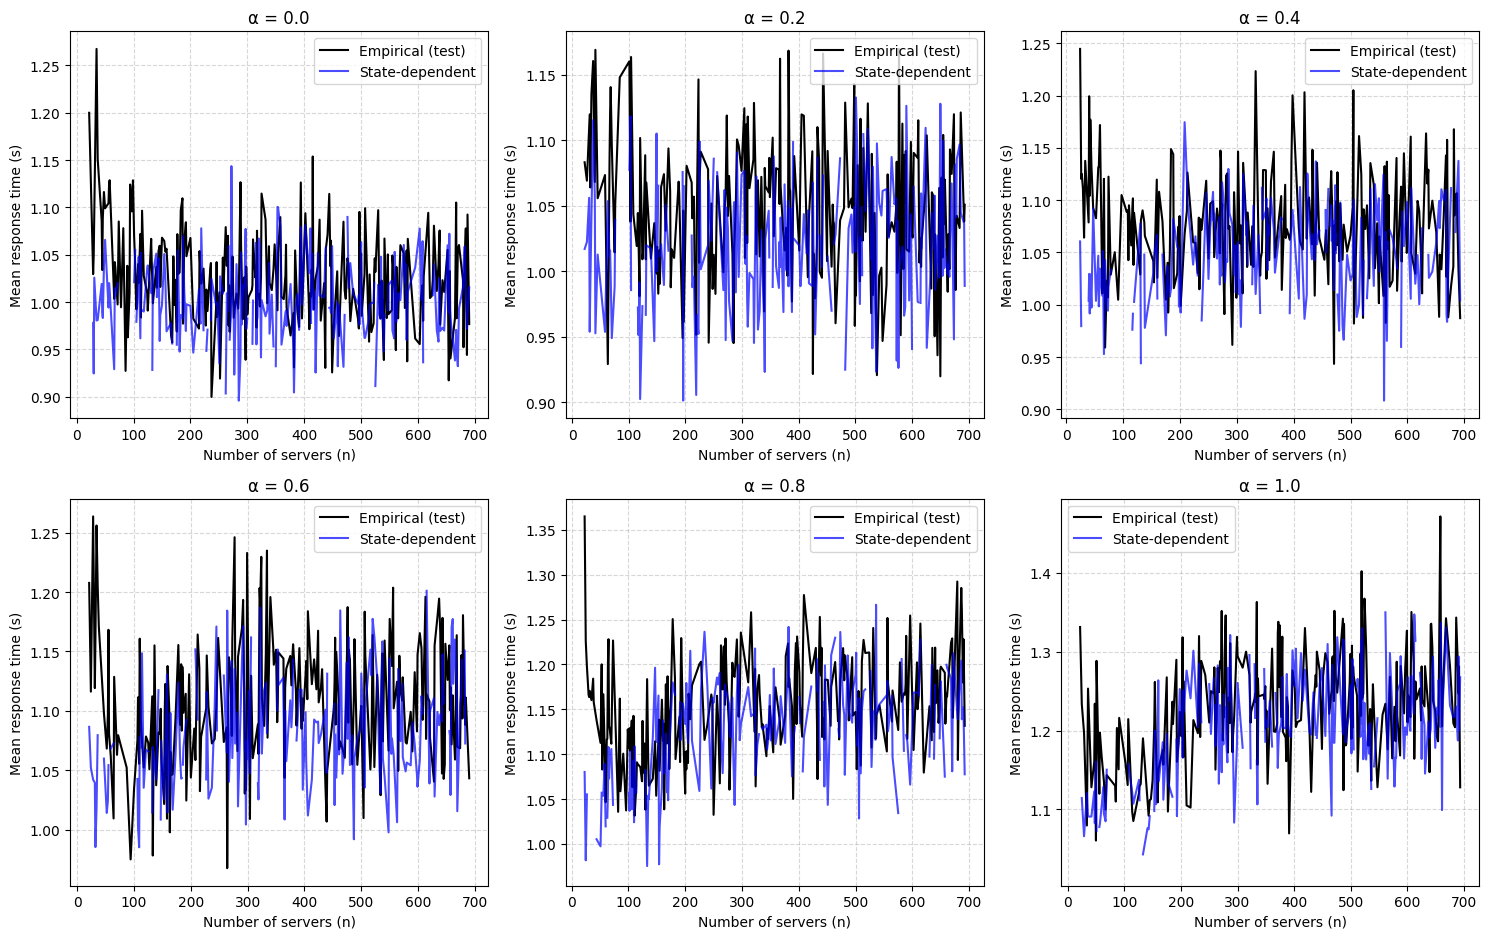

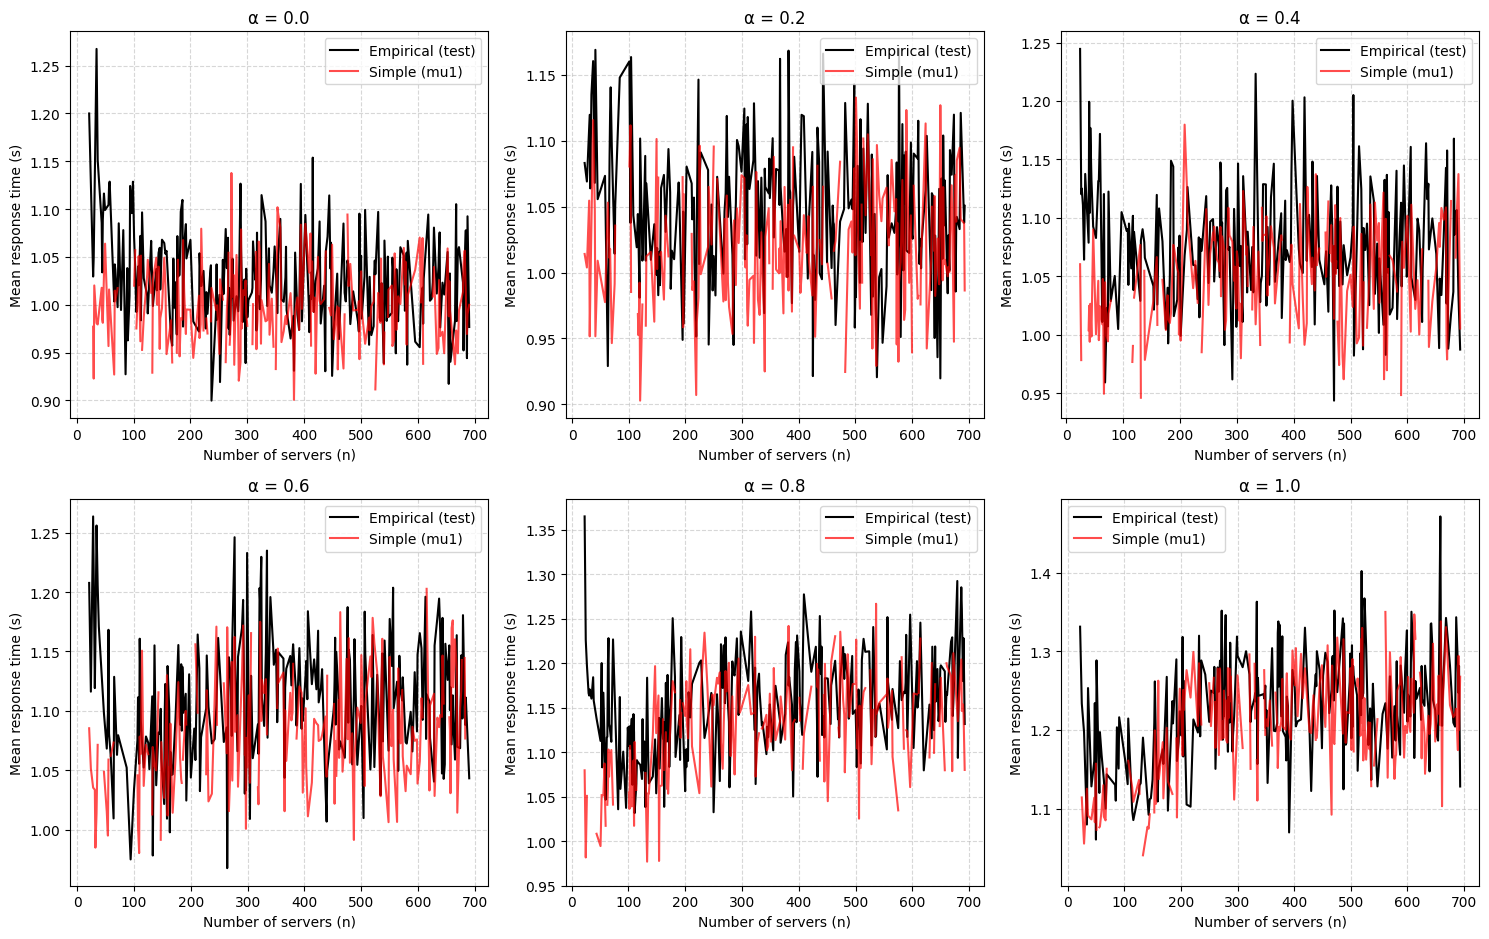

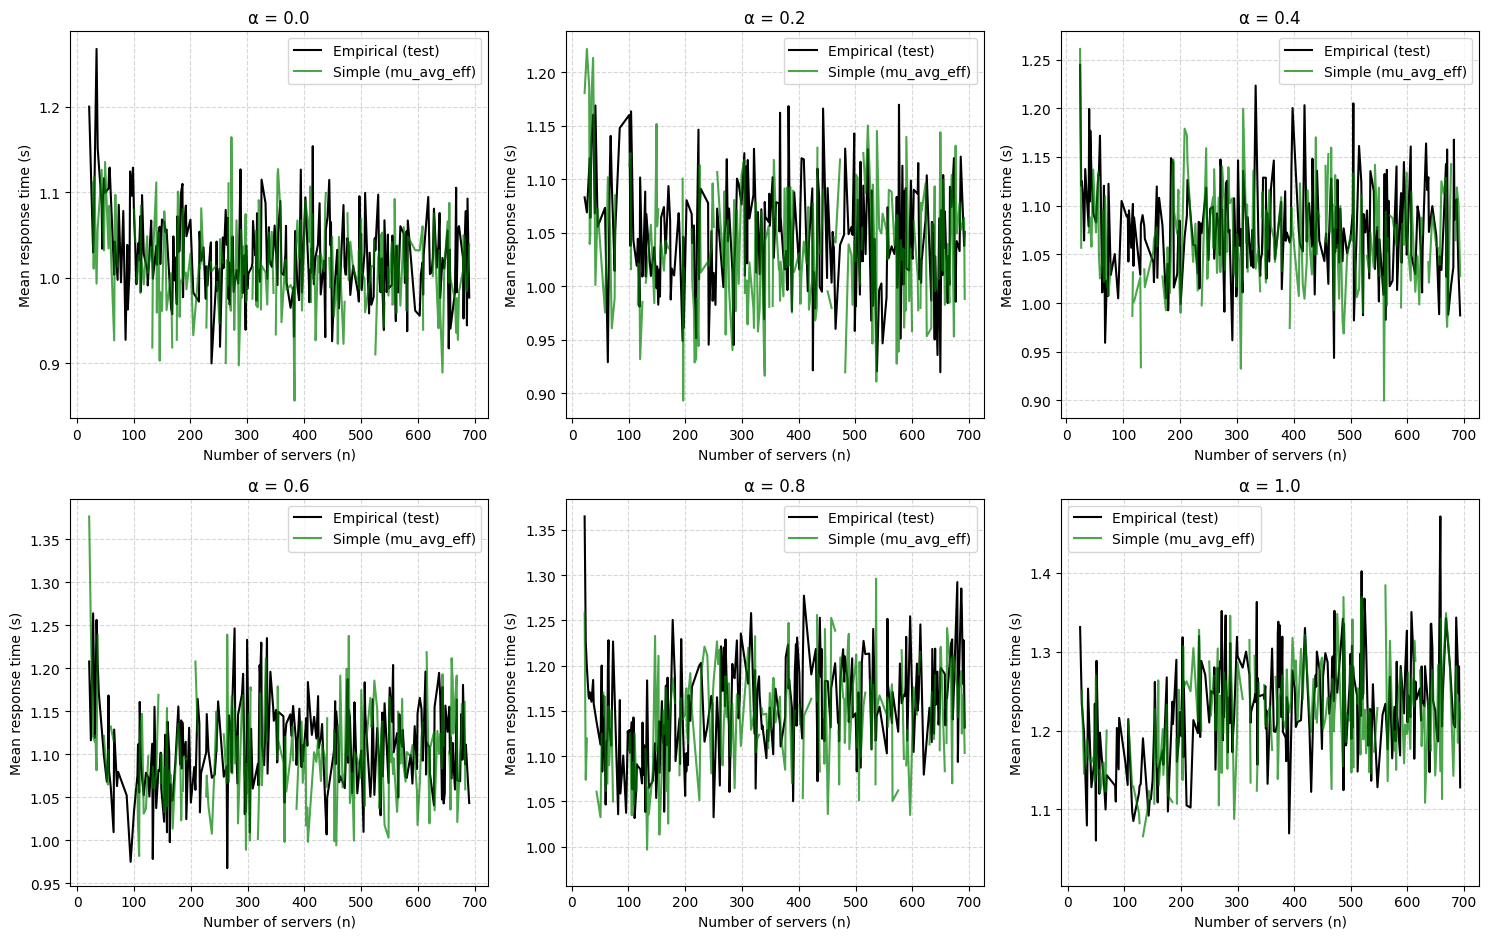

In [44]:
# After you have pred_df from the test evaluation
figs = plot_test_predictions(pred_df)

# Display each figure (or save)
for fig in figs:
    plt.show()

# Optionally save them
# figs[0].savefig('state_dependent.png', dpi=300)
# figs[1].savefig('simple_mu1.png', dpi=300)
# figs[2].savefig('simple_mu_avg.png', dpi=300)

## Prepare the training data from model training

In [45]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [46]:
# Compute empirical mean T per (n, alpha) for training and test sets
train_emp = train_df.groupby(['active_servers_num', 'alpha'])['client_measured_time'].mean().reset_index()
train_emp.columns = ['n', 'alpha', 'T_emp']
test_emp = test_df.groupby(['active_servers_num', 'alpha'])['client_measured_time'].mean().reset_index()
test_emp.columns = ['n', 'alpha', 'T_emp']

X_train = train_emp[['n', 'alpha']].values
y_train = train_emp['T_emp'].values
X_test = test_emp[['n', 'alpha']].values
y_test = test_emp['T_emp'].values

In [47]:
# Try importing XGBoost
try:
    import xgboost as xgb
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

def train_all_regression_models(models, X_train, y_train, X_test, y_test):
    """
    Train a suite of regression models and evaluate them on the test set.
    Returns a dictionary with predictions and metrics for each model.
    """
    results = {}
    trained_models = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        trained_models[name] = model
        y_pred = model.predict(X_test)
        
        # Compute metrics
        rmse, mae, mape = compare_results(y_test, y_pred)
        print(f"{name} | {format_comparison((rmse, mae, mape))}")

        results[name] = {
            'pred': y_pred,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape
        }
    
    return trained_models, results

In [48]:
# Declate the models to be trained
models = {
    'Linear Regression': LinearRegression(),
    'Polynomial (deg=2)': Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('linear', LinearRegression())
    ]),
    'Polynomial (deg=3)': Pipeline([
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('linear', LinearRegression())
    ]),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR (RBF)': SVR(kernel='rbf', gamma='scale', C=1.0)
}

# Add XGBoost if available
if HAS_XGBOOST:
    models['XGBoost'] = xgb.XGBRegressor(n_estimators=100, random_state=42)

# Train models and get results
trained_models, reg_results = train_all_regression_models(models, X_train, y_train, X_test, y_test)

# Create a DataFrame with test (n, alpha) and all regression predictions
reg_pred_df = test_emp[['n', 'alpha']].copy()
for name, res in reg_results.items():
    reg_pred_df[f'pred_{name}'] = res['pred']

merged_pred = pred_df.merge(reg_pred_df, on=['n', 'alpha'], how='left')

Linear Regression | RMSE: 0.0568 | MAE: 0.0448 | MAPE: 4.0433%
Polynomial (deg=2) | RMSE: 0.0536 | MAE: 0.0424 | MAPE: 3.8295%
Polynomial (deg=3) | RMSE: 0.0647 | MAE: 0.0511 | MAPE: 4.6101%
Decision Tree | RMSE: 0.0553 | MAE: 0.0432 | MAPE: 3.9047%
Random Forest | RMSE: 0.0593 | MAE: 0.0466 | MAPE: 4.2176%
SVR (RBF) | RMSE: 0.0854 | MAE: 0.0691 | MAPE: 6.2781%


In [49]:
def print_all_metrics(reg_results, analytical_metrics):
    """
    Print a table with RMSE, MAE, MAPE for both analytical and regression models.
    """
    # Combine metrics
    metrics_dict = {}
    # Add analytical metrics (assume they are in a dict with keys 'state_dependent', 'simple_mu1', 'simple_mu_avg')
    for key, (rmse, mae, mape) in analytical_metrics.items():
        metrics_dict[key] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    # Add regression metrics
    for name, res in reg_results.items():
        metrics_dict[name] = {'RMSE': res['RMSE'], 'MAE': res['MAE'], 'MAPE': res['MAPE']}
    
    # Convert to DataFrame for pretty printing
    df_metrics = pd.DataFrame(metrics_dict).T
    # Sort by RMSE (best first)
    df_metrics = df_metrics.sort_values('RMSE')
    
    print("\n" + "="*80)
    print("MODEL PERFORMANCE COMPARISON (Test Set)")
    print("="*80)
    print(df_metrics.round(4).to_string())
    print("="*80)
    
print_all_metrics(reg_results, analytical_metrics)


MODEL PERFORMANCE COMPARISON (Test Set)
                      RMSE     MAE    MAPE
Polynomial (deg=2)  0.0536  0.0424  3.8295
Decision Tree       0.0553  0.0432  3.9047
Linear Regression   0.0568  0.0448  4.0433
Random Forest       0.0593  0.0466  4.2176
Polynomial (deg=3)  0.0647  0.0511  4.6101
simple_mu_avg       0.0750  0.0590  5.3217
simple_mu1          0.0758  0.0595  5.3256
state_dependent     0.0763  0.0599  5.3630
SVR (RBF)           0.0854  0.0691  6.2781


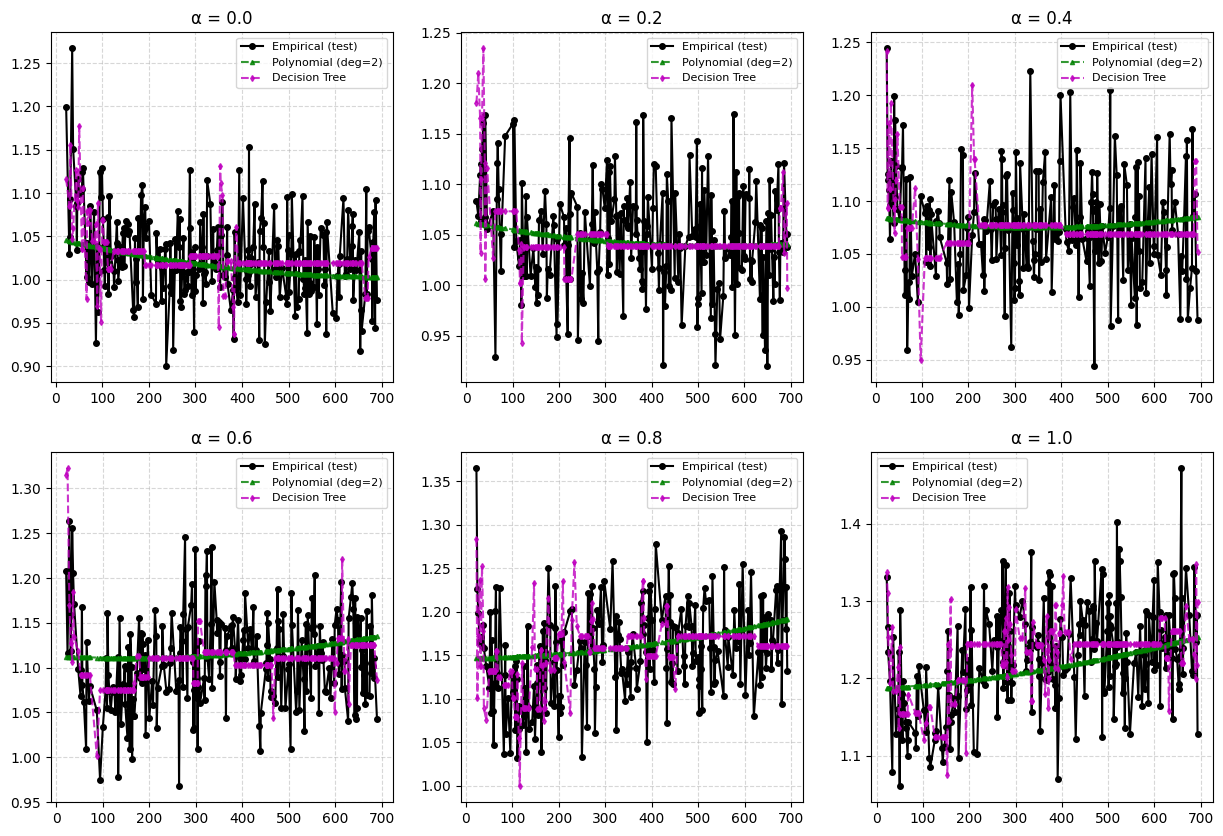

In [50]:
def plot_all_models(merged_pred, reg_results, alpha_values=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]):
    # Find the two best regression models by RMSE
    sorted_models = sorted(reg_results.items(), key=lambda x: x[1]['RMSE'])
    best_names = [name for name, _ in sorted_models[:2]]
    best_styles = ['g--^', 'm--d']  # assign styles
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for idx, alpha in enumerate(alpha_values):
        ax = axes[idx]
        df_alpha = merged_pred[merged_pred['alpha'] == alpha].sort_values('n')
        ax.plot(df_alpha['n'], df_alpha['T_emp'], 'ko-', label='Empirical (test)', markersize=4)
        # ax.plot(df_alpha['n'], df_alpha['T_pred_state'], 'b-s', label='State-dependent', markersize=4)
        # ax.plot(df_alpha['n'], df_alpha['T_pred_mu1'], 'r--d', label='Simple (mu1)', markersize=3)
        # ax.plot(df_alpha['n'], df_alpha['T_pred_mu_avg'], 'g-^', label='Simple (mu_avg)', markersize=3)
        
        # Plot best regression models
        for name, style in zip(best_names, best_styles):
            col = f'pred_{name}'
            if col in df_alpha.columns:
                ax.plot(df_alpha['n'], df_alpha[col], style, label=name, markersize=3, alpha=0.8)
        
        ax.set_title(f'α = {alpha}')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.5)
    return fig
    
fig = plot_all_models(merged_pred, reg_results)
plt.show()

In [51]:
def predict_simple_mu_avg(n, alpha, lam, mu_avg_eff):
    """
    Compute T using the average effective service rate.
    Returns (T, success_flag) where success_flag is True if no exception.
    """
    mu = mu_avg_eff.get((n, alpha))
    if mu is None or np.isnan(mu):
        return np.nan, False
    try:
        T = T_mmn(mu, lam, n)
        if np.isinf(T):
            return np.nan, False
        return T, True
    except Exception:
        return np.nan, False

In [52]:
def evaluate_hybrid(test_df, mu_d, mu1, mu_avg_eff, lam=0.3, poly_pred=None):
    """
    Evaluate state-dependent, simple_mu1, simple_mu_avg, and hybrid (mu_avg with poly fallback).
    """
    state_df_test = process_runs_for_state(test_df)
    emp_means = state_df_test.groupby(['n', 'alpha'])['client_measured_time'].mean().reset_index()
    emp_means.rename(columns={'client_measured_time': 'T_emp'}, inplace=True)
    
    # Get test n and alpha in order
    test_emp = test_df.groupby(['active_servers_num', 'alpha'])['client_measured_time'].mean().reset_index()
    test_emp.columns = ['n', 'alpha', 'T_emp']
    # We'll align with X_test order (same as test_emp)
    
    predictions = []
    for idx, row in test_emp.iterrows():
        n = int(row['n'])
        alpha = row['alpha']
        T_emp = row['T_emp']
        
        # State-dependent
        try:
            T_state = compute_T(n, lam, alpha, mu_d, fallback_mu_n_alpha=mu1)
        except Exception:
            T_state = np.nan
        
        # Simple mu1
        mu = mu1.get((n, alpha))
        T_mu1 = T_mmn(mu, lam, n) if mu is not None and not np.isnan(mu) else np.nan
        
        # Simple mu_avg (with exception catching)
        T_mu_avg, success = predict_simple_mu_avg(n, alpha, lam, mu_avg_eff)
        
        # Hybrid: if simple_mu_avg fails, use polynomial prediction (if provided)
        if success:
            T_hybrid = T_mu_avg
        else:
            # Use polynomial prediction for this row (aligned by index)
            if poly_pred is not None:
                T_hybrid = poly_pred[idx]
            else:
                T_hybrid = np.nan
        
        predictions.append({
            'n': n,
            'alpha': alpha,
            'T_emp': T_emp,
            # 'T_pred_state': T_state,
            'T_pred_mu1': T_mu1,
            'T_pred_mu_avg': T_mu_avg,
            'T_pred_hybrid': T_hybrid,
            'mu_avg_success': success
        })
    
    pred_df = pd.DataFrame(predictions)
    return pred_df

In [53]:
def plot_hybrid(pred_df, alpha_values=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for idx, alpha in enumerate(alpha_values):
        ax = axes[idx]
        df_alpha = pred_df[pred_df['alpha'] == alpha].sort_values('n')
        ax.plot(df_alpha['n'], df_alpha['T_emp'], 'k-', label='Empirical', markersize=4)
        # ax.plot(df_alpha['n'], df_alpha['T_pred_state'], 'b-s', label='State-dep.', markersize=4)
        # ax.plot(df_alpha['n'], df_alpha['T_pred_mu1'], 'r--d', label='Simple mu1', markersize=3)
        # ax.plot(df_alpha['n'], df_alpha['T_pred_mu_avg'], 'g-^', label='Simple mu_avg', markersize=3)
        ax.plot(df_alpha['n'], df_alpha['T_pred_hybrid'], 'm-', label='Prediction', markersize=4, alpha=0.7)
        ax.set_title(f'α = {alpha}')
        ax.legend(fontsize=7)
        ax.grid(True, linestyle='--', alpha=0.5)
    return fig

In [54]:
def plot_hybrid_smooth(pred_df, alpha_values=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for idx, alpha in enumerate(alpha_values):
        ax = axes[idx]
        df_alpha = pred_df[pred_df['alpha'] == alpha].sort_values('n')
        ax.plot(df_alpha['n'],savgol_filter(df_alpha['T_emp'], window_length, polyorder), 'k-', label='Empirical', markersize=4)
        # ax.plot(df_alpha['n'], df_alpha['T_pred_state'], 'b-s', label='State-dep.', markersize=4)
        # ax.plot(df_alpha['n'], df_alpha['T_pred_mu1'], 'r--d', label='Simple mu1', markersize=3)
        # ax.plot(df_alpha['n'], df_alpha['T_pred_mu_avg'], 'g-^', label='Simple mu_avg', markersize=3)
        ax.plot(df_alpha['n'], savgol_filter(df_alpha['T_pred_hybrid'], window_length, polyorder), 'b-', label='Prediction', markersize=4, alpha=0.7)
        ax.set_title(f'α = {alpha}')
        ax.legend(fontsize=7)
        ax.grid(True, linestyle='--', alpha=0.5)
    return fig

In [55]:
# Constants
LAMBDA = 0.3

poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear', LinearRegression())
])
poly_model.fit(X_train, y_train)
poly_pred = poly_model.predict(X_test)

# 4. Evaluate hybrid model on test data
pred_df = evaluate_hybrid(test_df, mu_d, mu1, mu_avg_eff, lam=LAMBDA, poly_pred=poly_pred)

In [56]:
pred_df.head()

,n,alpha,T_emp,T_pred_mu1,T_pred_mu_avg,T_pred_hybrid,mu_avg_success
0,21,0.6,1.207664,1.085294,1.376602,1.376602,True
1,22,0.0,1.199862,NaN,NaN,1.045218,False
2,22,0.2,1.083116,1.014087,1.185363,1.185363,True
3,22,1.0,1.331304,1.136599,1.347187,1.347187,True
4,23,0.8,1.364992,1.079597,1.258377,1.258377,True


In [57]:
def compute_all_metrics_per_alpha(pred_df, pred_cols=None):
    """
    Compute RMSE, MAE, MAPE per alpha for each prediction column.

    Parameters
    ----------
    pred_df : pd.DataFrame
        Must contain columns: 'n', 'alpha', 'T_emp', and prediction columns.
    pred_cols : list of str, optional
        List of column names to evaluate. If None, use all columns starting with 'T_pred_'.

    Returns
    -------
    dict
        keys: model names (column names), values: dict with alpha -> (rmse, mae, mape)
    """
    if pred_cols is None:
        pred_cols = [col for col in pred_df.columns if col.startswith('T_pred_')]
    
    all_metrics = {}
    for col in pred_cols:
        metrics = {}
        alphas = pred_df['alpha'].unique()
        for alpha in alphas:
            df_alpha = pred_df[pred_df['alpha'] == alpha].dropna(subset=['T_emp', col])
            if len(df_alpha) == 0:
                metrics[alpha] = (np.nan, np.nan, np.nan)
                continue
            y_true = df_alpha['T_emp'].values
            y_pred = df_alpha[col].values
            metrics[alpha] = compare_results(y_true, y_pred)
        all_metrics[col] = metrics
    return all_metrics

# Compute metrics for all prediction columns
all_metrics = compute_all_metrics_per_alpha(pred_df)

# Print a table for each model
for model_name, metrics in all_metrics.items():
    print(f"\n{'='*40}")
    print(f"Model: {model_name}")
    print('='*40)
    print_metrics_table(metrics)


Model: T_pred_mu1

MODEL PERFORMANCE METRICS PER α
           RMSE     MAE    MAPE
0.0      0.0686  0.0547  5.2623
0.2      0.0788  0.0625  5.9217
0.4      0.0748  0.0580  5.3105
0.6      0.0716  0.0566  5.0516
0.8      0.0782  0.0612  5.2404
1.0      0.0825  0.0642  5.1670
Average  0.0758  0.0595  5.3256
Average RMSE: 0.0758  |  Average MAE: 0.0595  |  Average MAPE: 5.3256%

Model: T_pred_mu_avg

MODEL PERFORMANCE METRICS PER α
           RMSE     MAE    MAPE
0.0      0.0691  0.0549  5.3253
0.2      0.0800  0.0638  6.0889
0.4      0.0706  0.0551  5.0942
0.6      0.0714  0.0566  5.0976
0.8      0.0737  0.0599  5.1600
1.0      0.0818  0.0620  5.0248
Average  0.0744  0.0587  5.2985
Average RMSE: 0.0744  |  Average MAE: 0.0587  |  Average MAPE: 5.2985%

Model: T_pred_hybrid

MODEL PERFORMANCE METRICS PER α
           RMSE     MAE    MAPE
0.0      0.0669  0.0522  5.0549
0.2      0.0766  0.0600  5.7290
0.4      0.0669  0.0514  4.7523
0.6      0.0690  0.0547  4.9324
0.8      0.0702  0.0567 

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def plot_mu_model_across_alphas(
    get_mu,                     # функция get_mu(n, alpha, i) -> μ
    experiment_data_df,         # сырые данные: alpha, active_servers_num, client_measured_time
    state_df,                   # per‑request данные: n, alpha, client_measured_time (для CI)
    lam=0.3,
    alphas=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0),
    n_range=None,
    confidence_level=0.95,
    figsize=(15, 10),
    analytical_line_width=3,
    save_path=None
):
    """
    Строит 2×3 сетку подграфиков для всех alpha, сравнивая эмпирические данные
    с предсказаниями модели, использующей заданную функцию get_mu.

    Параметры
    ----------
    get_mu : callable
        Функция с сигнатурой get_mu(n, alpha, i) -> float (интенсивность обслуживания).
    experiment_data_df : pd.DataFrame
        Содержит колонки: alpha, active_servers_num, client_measured_time.
    state_df : pd.DataFrame
        Содержит колонки: n, alpha, client_measured_time (для построения CI).
    lam : float
        Интенсивность поступления (λ).
    alphas : iterable
        Список значений alpha для отображения (по умолчанию 0.0..1.0).
    n_range : iterable, optional
        Список значений n для предсказаний. Если None, берутся из empirical данных.
    confidence_level : float
        Уровень доверия для интервалов (по умолчанию 0.95).
    figsize : tuple
        Размер фигуры.
    save_path : str, optional
        Путь для сохранения рисунка.
    """
    # 1. Вычисляем эмпирические CI для каждого alpha
    alphas = sorted(alphas)
    emp_stats_by_alpha = {}
    for alpha in alphas:
        df_a = state_df[state_df['alpha'] == alpha]
        if df_a.empty:
            continue
        emp_stats = df_a.groupby('n')['client_measured_time'].agg(
            mean='mean',
            std='std',
            count='size'
        ).reset_index()
        t_val = stats.t.ppf(1 - (1 - confidence_level)/2, emp_stats['count'] - 1)
        emp_stats['sem'] = emp_stats['std'] / np.sqrt(emp_stats['count'])
        emp_stats['ci_lower'] = emp_stats['mean'] - t_val * emp_stats['sem']
        emp_stats['ci_upper'] = emp_stats['mean'] + t_val * emp_stats['sem']
        emp_stats = emp_stats.sort_values('n')
        emp_stats_by_alpha[alpha] = {
            'n': emp_stats['n'].values,
            'mean': emp_stats['mean'].values,
            'lower': emp_stats['ci_lower'].values,
            'upper': emp_stats['ci_upper'].values
        }

    # Если n_range не задан, берём объединение всех n из эмпирических данных
    if n_range is None:
        all_n = set()
        for emp_stat in emp_stats_by_alpha.values():
            all_n.update(emp_stat['n'])
        n_range = sorted(all_n)

    # 2. Предварительно вычисляем эмпирические средние для (alpha, n) из experiment_data_df
    emp_means_full = experiment_data_df.groupby(['alpha', 'active_servers_num'])['client_measured_time'].mean()

    # 3. Подготовка подграфиков
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    metrics = {}  # для хранения метрик по alpha

    for idx, alpha in enumerate(alphas):
        ax = axes[idx]

        # Эмпирические CI для этого alpha
        if alpha in emp_stats_by_alpha:
            emp_stat = emp_stats_by_alpha[alpha]
            ax.plot(emp_stat['n'], emp_stat['mean'], 'k-', label='Empirical mean', markersize=3, linewidth=1.5)
            ax.fill_between(emp_stat['n'], emp_stat['lower'], emp_stat['upper'],
                            color='gray', alpha=0.3, label=f'{int(confidence_level*100)}% CI')
        else:
            ax.text(0.5, 0.5, f'No empirical data for α={alpha}', ha='center', va='center')
            ax.set_title(f'α = {alpha}')
            ax.grid(True)
            continue

        # 4. Предсказания модели для всех n в n_range
        T_pred = []
        valid_n = []
        for n in n_range:
            try:
                T = predict_T(n, alpha, lam, get_mu=get_mu)  # предполагаем, что predict_T принимает get_mu
                if not np.isnan(T) and not np.isinf(T):
                    T_pred.append(T)
                    valid_n.append(n)
            except Exception:
                continue

        # 5. Собираем эмпирические значения только для тех n, для которых есть предсказания
        y_true = []
        y_pred = []
        for n in valid_n:
            try:
                y_true.append(emp_means_full.loc[(alpha, n)])
                y_pred.append(T_pred[valid_n.index(n)])
            except KeyError:
                continue

        # 6. Вычисляем метрики
        if len(y_true) > 0:
            try:
                rmse, mae, mape = compare_results(y_true, y_pred)
                metrics[alpha] = (rmse, mae, mape)
                metrics_str = format_comparison((rmse, mae, mape), decimals=4)
            except Exception as e:
                metrics_str = f"Metrics error: {e}"
        else:
            metrics[alpha] = (np.nan, np.nan, np.nan)
            metrics_str = "No valid predictions"

        # 7. Рисуем предсказания (только для valid_n, чтобы не было разрывов)
        ax.plot(valid_n, y_pred, 'b-', label='Prediction (model)', markersize=3, linewidth=analytical_line_width)

        # Оформление подграфика
        ax.set_xlabel('Number of servers (n)')
        ax.set_ylabel('Mean response time (s)')
        ax.set_title(f'α = {alpha}')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=8, loc='lower center')

        # Текст с метриками
        ax.text(0.02, 0.98, metrics_str, transform=ax.transAxes,
                verticalalignment='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Удаляем пустые подграфики (если alphas меньше 6)
    for j in range(len(alphas), 6):
        fig.delaxes(axes[j])

    # 8. Печатаем таблицу метрик
    print("\n" + "="*60)
    print("MODEL PERFORMANCE METRICS PER α")
    print("="*60)
    for alpha, (rmse, mae, mape) in metrics.items():
        print(f"α={alpha:.1f}: RMSE={rmse:.4f}  MAE={mae:.4f}  MAPE={mape:.2f}%")
    # Среднее по alpha
    avg_rmse = np.nanmean([m[0] for m in metrics.values()])
    avg_mae  = np.nanmean([m[1] for m in metrics.values()])
    avg_mape = np.nanmean([m[2] for m in metrics.values()])
    if not np.isnan(avg_rmse):
        print("-"*60)
        print(f"Average: RMSE={avg_rmse:.4f}  MAE={avg_mae:.4f}  MAPE={avg_mape:.2f}%")
    print("="*60)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    return fig, metrics

In [59]:
import numpy as np

def build_fallback_from_model(model, n_values, alphas, min_mu=0.01):
    """
    Строит словарь fallback_mu_n_alpha из обученной модели.

    Параметры
    ----------
    model : sklearn-совместимая модель
        Обученная модель, которая принимает на вход массив признаков [n, alpha]
        и возвращает предсказанное значение μ.
    n_values : iterable
        Список или массив значений n (например, range(21, 694)).
    alphas : iterable
        Список значений alpha (например, [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]).
    min_mu : float, optional
        Минимальное допустимое значение μ (чтобы избежать деления на ноль).

    Возвращает
    ----------
    dict
        Словарь с ключами (n, alpha) и значениями μ.
    """
    fallback = {}
    for n in n_values:
        for alpha in alphas:
            X = np.array([[n, alpha]])
            mu = model.predict(X)[0]
            # Гарантируем положительность
            mu = max(min_mu, mu)
            fallback[(n, alpha)] = 1 / mu
    return fallback

In [60]:
# 2. Задаём диапазоны для fallback
n_range = range(21, 694)
alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# 3. Для выбранной модели строим fallback-словарь
chosen_model = trained_models['Polynomial (deg=2)']
fallback_mu_poly = build_fallback_from_model(chosen_model, n_range, alphas, min_mu=0.01)


MODEL PERFORMANCE METRICS PER α
α=0.0: RMSE=0.0393  MAE=0.0306  MAPE=2.94%
α=0.2: RMSE=0.0397  MAE=0.0305  MAPE=2.90%
α=0.4: RMSE=0.0377  MAE=0.0285  MAPE=2.66%
α=0.6: RMSE=0.0423  MAE=0.0331  MAPE=3.01%
α=0.8: RMSE=0.0421  MAE=0.0331  MAPE=2.89%
α=1.0: RMSE=0.0504  MAE=0.0408  MAPE=3.34%
------------------------------------------------------------
Average: RMSE=0.0419  MAE=0.0328  MAPE=2.96%


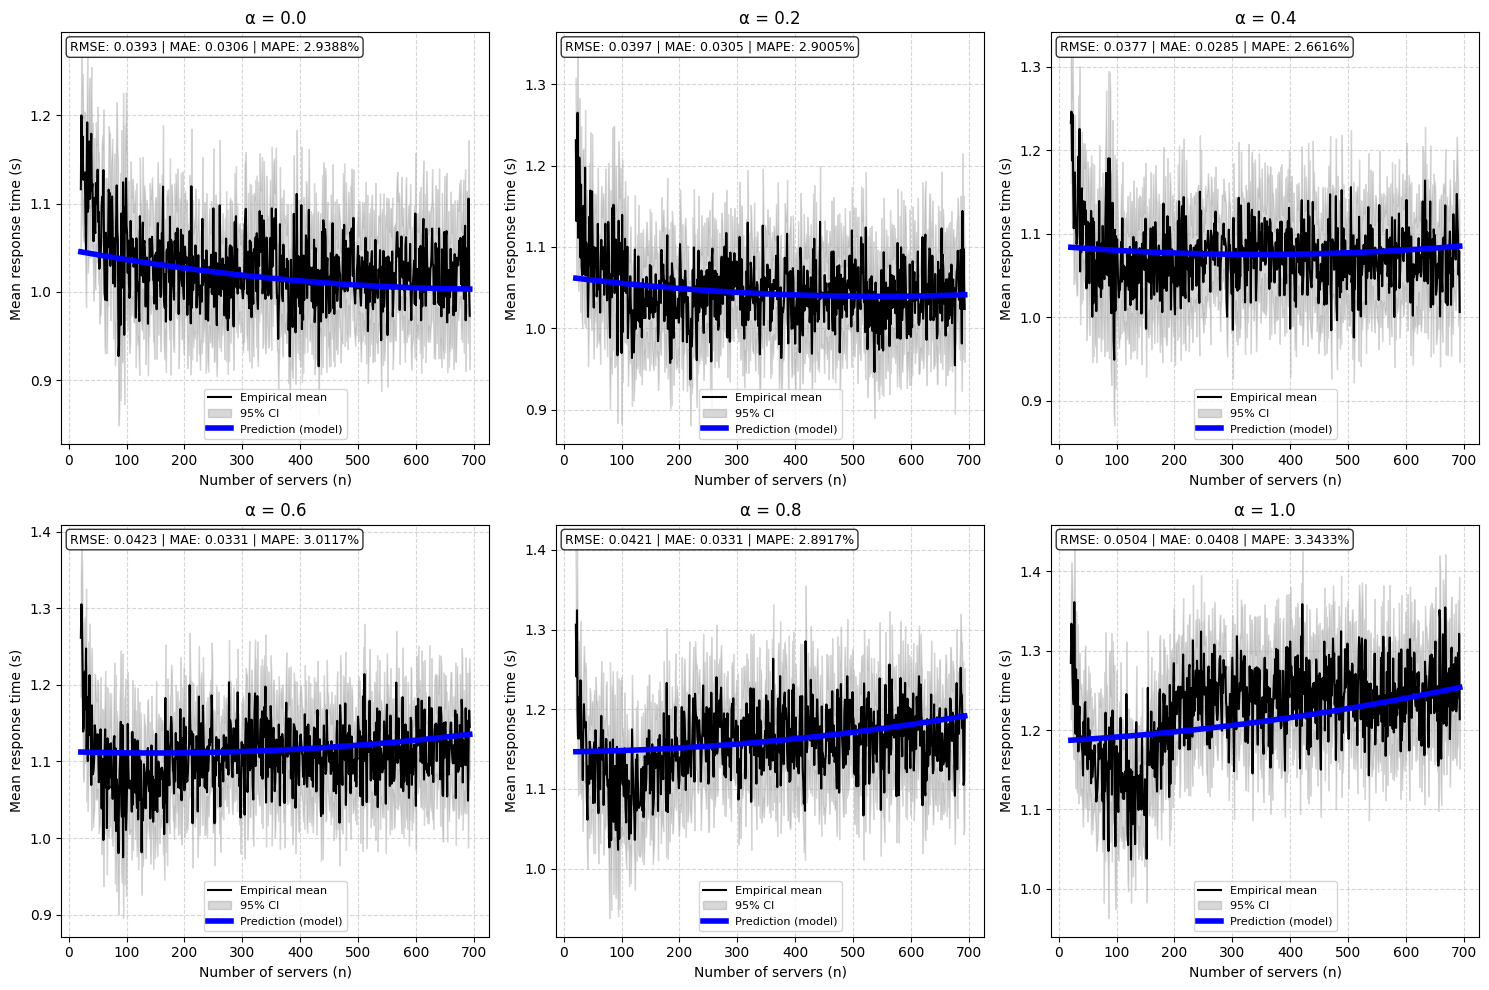

In [61]:
# Создаём getter для μ
get_mu = make_mu_getter({}, fallback_mu_poly)

# Строим графики
fig, metrics = plot_mu_model_across_alphas(
    get_mu=get_mu,
    experiment_data_df=experiment_data_df,
    state_df=state_df,
    lam=0.3,
    alphas=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    n_range=range(21, 694),
    analytical_line_width=4,
    save_path='QueuingModel_mu_alpha.png',
)
plt.show()


MODEL PERFORMANCE METRICS PER α
α=0.0: RMSE=0.0388  MAE=0.0297  MAPE=2.85%
α=0.2: RMSE=0.0378  MAE=0.0294  MAPE=2.79%
α=0.4: RMSE=0.0368  MAE=0.0279  MAPE=2.60%
α=0.6: RMSE=0.0406  MAE=0.0315  MAPE=2.85%
α=0.8: RMSE=0.0411  MAE=0.0321  MAPE=2.78%
α=1.0: RMSE=0.0512  MAE=0.0418  MAPE=3.40%
------------------------------------------------------------
Average: RMSE=0.0411  MAE=0.0321  MAPE=2.88%


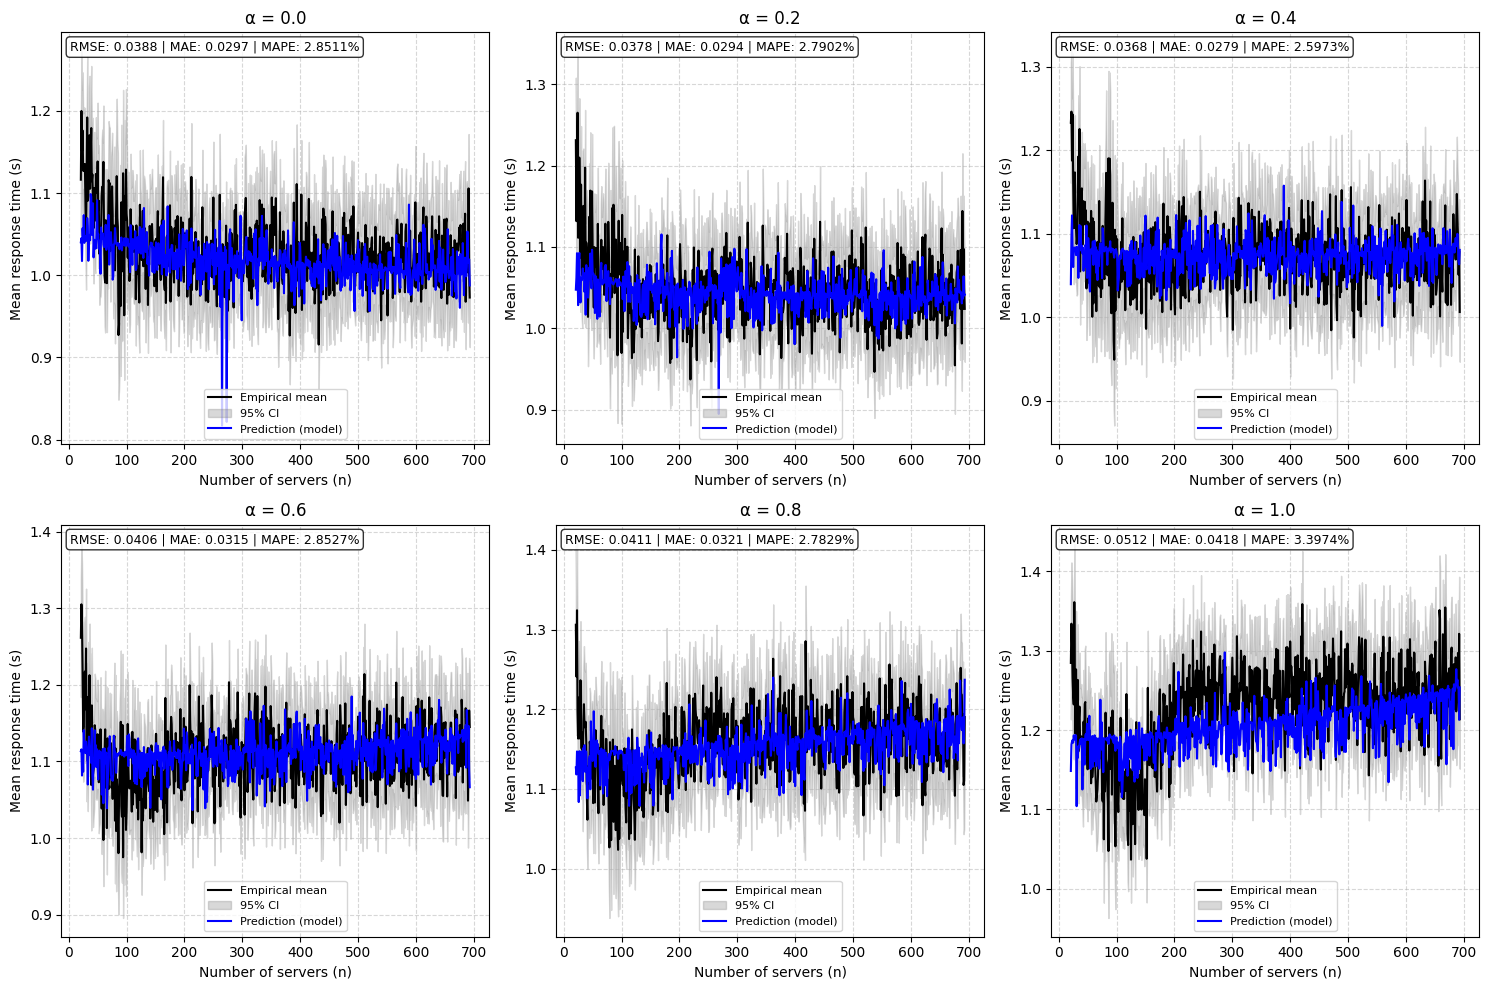

In [62]:
# Создаём getter для μ
get_mu = make_mu_getter(mu_d, fallback_mu_poly)

# Строим графики
fig, metrics = plot_mu_model_across_alphas(
    get_mu=get_mu,
    experiment_data_df=experiment_data_df,
    state_df=state_df,
    lam=0.3,
    alphas=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    n_range=range(21, 694),
    analytical_line_width=1.5,
    save_path='QueuingModel_mu_alpha_i.png'
)
plt.show()

In [63]:
import simpy
import random
import numpy as np

def simulate_mm_s_state_dependent(
    lam,                # интенсивность поступления
    n,                  # число серверов
    alpha,              # параметр alpha
    get_mu,             # функция get_mu(n, alpha, i) -> μ
    num_requests=30000, # общее число заявок (включая warmup)
    warmup=3000,        # число заявок для разогрева
    seed=None
):
    """
    Симуляция M/M/n очереди с зависящей от состояния интенсивностью обслуживания μ(n, α, i).

    Возвращает среднее время ответа (после warmup) или inf, если заявок нет.
    """
    if seed is not None:
        random.seed(seed)
    
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=n)
    
    sojourn_times = []
    served = 0
    system_size = 0   # текущее число заявок в системе (включая обслуживаемые и очередь)
    done = env.event()
    
    def service(env, arrival_time):
        nonlocal served, system_size
        # Увеличиваем счётчик системы при поступлении (до запроса ресурса)
        system_size += 1
        
        # Запрашиваем сервер (блокируется, если все заняты)
        with server.request() as req:
            yield req
            
            # В момент начала обслуживания определяем состояние системы
            # system_size включает текущую заявку и все, что уже есть
            i = system_size
            
            # Получаем интенсивность обслуживания для данного состояния
            try:
                mu = get_mu(n, alpha, i)
            except Exception as e:
                # Если get_mu выбросил ошибку, используем очень маленькую интенсивность
                # или пропускаем заявку; лучше завершить с ошибкой
                raise RuntimeError(f"Failed to get mu for n={n}, alpha={alpha}, i={i}: {e}")
            
            # Генерируем время обслуживания из экспоненциального распределения
            service_time = random.expovariate(mu)
            yield env.timeout(service_time)
            
            # Завершение обслуживания: уменьшаем счётчик системы
            system_size -= 1
            
            # Собираем статистику после warmup
            sojourn = env.now - arrival_time
            served += 1
            if served > warmup:
                sojourn_times.append(sojourn)
            
            if served >= num_requests + warmup:
                done.succeed()
    
    def arrivals():
        while True:
            yield env.timeout(random.expovariate(lam))
            arrival_time = env.now
            env.process(service(env, arrival_time))
    
    env.process(arrivals())
    env.run(until=done)
    
    if sojourn_times:
        return np.mean(sojourn_times)
    else:
        return float('inf')

In [64]:
# Создаём get_mu (например, с полиномиальным fallback)
get_mu = make_mu_getter(mu_d, fallback_mu_poly)

# Запускаем симуляцию для n=50, alpha=0.4
T_sim = simulate_mm_s_state_dependent(
    lam=0.3,
    n=50,
    alpha=0.4,
    get_mu=get_mu,
    num_requests=30000,
    warmup=3000,
    seed=42
)

print(f"Simulated mean response time: {T_sim:.4f} s")

Simulated mean response time: 1.0603 s


In [67]:
import hashlib
import os
import pickle
import multiprocessing as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import savgol_filter
from tqdm import tqdm

# ---------- Симуляция одной точки (возвращает rep_id) ----------
def simulate_single_point(params):
    lam, n, alpha, mu_n_alpha_i, fallback_mu_n_alpha, num_requests, warmup, seed, label, rep_id = params
    def get_mu_local(nn, aa, ii):
        key = (nn, aa, ii)
        if key in mu_n_alpha_i:
            return mu_n_alpha_i[key]
        if fallback_mu_n_alpha is not None:
            fb_key = (nn, aa)
            if fb_key in fallback_mu_n_alpha:
                return fallback_mu_n_alpha[fb_key]
        raise ValueError(f"Missing μ for n={nn}, alpha={aa}, i={ii}")
    try:
        T = simulate_mm_s_state_dependent(
            lam=lam, n=n, alpha=alpha, get_mu=get_mu_local,
            num_requests=num_requests, warmup=warmup, seed=seed
        )
        return (n, alpha, label, rep_id, T)
    except Exception:
        return (n, alpha, label, rep_id, float('inf'))

def _get_cache_key(lam, alphas, n_range, sim_configs):
    config_str = f"{lam}_{tuple(alphas)}_{tuple(n_range)}_"
    for c in sim_configs:
        config_str += f"{c['replications']}_{c['requests']}_{c['warmup']}_{c['max_points']}_{c['label']}_"
    return hashlib.md5(config_str.encode()).hexdigest()

def plot_analytical_vs_simulations(
    experiment_data_df,
    state_df,
    mu_n_alpha_i,
    fallback_mu_n_alpha=None,
    lam=0.3,
    alphas=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0),
    n_range=None,
    sim_configs=None,
    confidence_level=0.95,
    smooth=True,
    window_length=51,
    polyorder=3,
    figsize=(15, 10),
    save_path=None,
    seed_base=42,
    n_workers=None,
    cache_path=None,
    force_recompute=False,
    compute_ci=True,          # включить расчёт CI
    ci_level=0.95             # уровень доверия для CI
):
    if sim_configs is None:
        sim_configs = []
    
    alphas = sorted(alphas)
    
    # Хэш для кэша
    cache_hash = _get_cache_key(lam, alphas, n_range, sim_configs)
    if cache_path is not None:
        cache_file = f"{cache_path}_{cache_hash}.pkl"
    else:
        cache_file = None
    
    # ----- Эмпирические CI (для отображения на графиках) -----
    emp_stats_by_alpha = {}
    for alpha in alphas:
        df_a = state_df[state_df['alpha'] == alpha]
        if df_a.empty:
            continue
        emp_stats = df_a.groupby('n')['client_measured_time'].agg(
            mean='mean', std='std', count='size'
        ).reset_index()
        t_val = stats.t.ppf(1 - (1 - confidence_level)/2, emp_stats['count'] - 1)
        emp_stats['sem'] = emp_stats['std'] / np.sqrt(emp_stats['count'])
        emp_stats['ci_lower'] = emp_stats['mean'] - t_val * emp_stats['sem']
        emp_stats['ci_upper'] = emp_stats['mean'] + t_val * emp_stats['sem']
        emp_stats = emp_stats.sort_values('n')
        emp_stats_by_alpha[alpha] = {
            'n': emp_stats['n'].values,
            'mean': emp_stats['mean'].values,
            'lower': emp_stats['ci_lower'].values,
            'upper': emp_stats['ci_upper'].values
        }
    
    if n_range is None:
        all_n = set()
        for est in emp_stats_by_alpha.values():
            all_n.update(est['n'])
        n_range = sorted(all_n)
    else:
        n_range = sorted(n_range)
    
    emp_means_full = experiment_data_df.groupby(['alpha', 'active_servers_num'])['client_measured_time'].mean()
    
    # Подготовка графиков
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()
    
    n_sim = len(sim_configs)
    sim_colors = plt.cm.Oranges(np.linspace(0.4, 0.9, max(1, n_sim))) if n_sim > 0 else []
    sim_styles = ['--', '-.', ':', (0, (5, 1)), (0, (3, 1, 1, 1))]
    
    # Словари для хранения метрик по репликациям
    all_metrics_empirical = {}   # (alpha, label) -> список (rmse, mae, mape) по репликам
    all_metrics_analytical = {}  # (alpha, label) -> список (rmse, mae, mape) по репликам
    
    # Глобальный get_mu для аналитики
    def get_mu_global(nn, aa, ii):
        key = (nn, aa, ii)
        if key in mu_n_alpha_i:
            return mu_n_alpha_i[key]
        if fallback_mu_n_alpha is not None:
            fb_key = (nn, aa)
            if fb_key in fallback_mu_n_alpha:
                return fallback_mu_n_alpha[fb_key]
        raise ValueError(f"Missing μ for n={nn}, alpha={aa}, i={ii}")
    
    # Кэш симуляций
    sim_results_cache = {}
    if cache_file is not None and os.path.exists(cache_file) and not force_recompute:
        with open(cache_file, 'rb') as f:
            sim_results_cache = pickle.load(f)
        print(f"Загружен общий кэш симуляций: {cache_file}")
    
    for idx, alpha in enumerate(alphas):
        ax = axes[idx]
        
        # ---- Аналитическая кривая ----
        T_analytical = []
        for n in n_range:
            try:
                T = predict_T(n, alpha, lam, get_mu=get_mu_global)
                T_analytical.append(T if not np.isinf(T) else np.nan)
            except Exception:
                T_analytical.append(np.nan)
        T_analytical = np.array(T_analytical)
        mask = ~np.isnan(T_analytical)
        n_anal = np.array(n_range)[mask]
        y_anal = T_analytical[mask]
        if len(n_anal) > 0:
            if smooth and len(n_anal) >= 5:
                win = min(window_length, len(n_anal)-1 if len(n_anal)%2==1 else len(n_anal)-2)
                if win >= 3:
                    y_anal = savgol_filter(y_anal, win, polyorder)
            ax.plot(n_anal, y_anal, '-', color='blue', linewidth=2, label='Analytical')
        else:
            print(f"Warning: No analytical points for alpha={alpha}")
        
        # Словарь для быстрого доступа к аналитике по n
        T_analytical_dict = {n: T_analytical[i] for i, n in enumerate(n_range) if not np.isnan(T_analytical[i])}
        
        # ---- Формируем задачи для симуляций ----
        tasks = []
        for config in sim_configs:
            reps = config.get('replications', 1)
            reqs = config.get('requests', 30000)
            warm = config.get('warmup', 3000)
            max_pts = config.get('max_points', None)
            label = config.get('label', f'Sim')
            n_sim_list = n_range
            if max_pts is not None and len(n_sim_list) > max_pts:
                indices = np.linspace(0, len(n_sim_list)-1, max_pts, dtype=int)
                n_sim_list = [n_sim_list[i] for i in indices]
            for n in n_sim_list:
                for rep_id in range(reps):
                    seed = seed_base + rep_id + idx*10000 + len(tasks)
                    tasks.append((lam, n, alpha, mu_n_alpha_i, fallback_mu_n_alpha,
                                  reqs, warm, seed, label, rep_id))
        
        results = []
        if tasks:
            cache_key_alpha = f"sim_{alpha}"
            if cache_file is not None and cache_key_alpha in sim_results_cache and not force_recompute:
                results = sim_results_cache[cache_key_alpha]
                print(f"Загружено из кэша для α={alpha}: {len(results)} точек")
            else:
                with mp.Pool(processes=n_workers or mp.cpu_count()) as pool:
                    results_iter = pool.imap(simulate_single_point, tasks)
                    results = list(tqdm(results_iter, total=len(tasks),
                                        desc=f"Симуляции α={alpha}"))
                sim_results_cache[cache_key_alpha] = results
                if cache_file is not None:
                    with open(cache_file, 'wb') as f:
                        pickle.dump(sim_results_cache, f)
            
            # ---- Агрегация результатов ----
            df_sim = pd.DataFrame(results, columns=['n', 'alpha', 'label', 'rep_id', 'T_sim'])
            
            # Для каждой конфигурации (label) и alpha вычисляем метрики по репликам
            for config in sim_configs:
                label = config.get('label', 'Sim')
                df_cfg = df_sim[df_sim['label'] == label]
                if df_cfg.empty:
                    continue
                
                # Получаем список уникальных реплик
                rep_ids = df_cfg['rep_id'].unique()
                
                # Списки для хранения метрик по репликам
                rmse_emp_list, mae_emp_list, mape_emp_list = [], [], []
                rmse_anal_list, mae_anal_list, mape_anal_list = [], [], []
                
                # Для каждой реплики вычисляем метрики
                for rep in rep_ids:
                    df_rep = df_cfg[df_cfg['rep_id'] == rep]
                    # Сортируем по n
                    df_rep = df_rep.sort_values('n')
                    n_s = df_rep['n'].values
                    y_s = df_rep['T_sim'].values
                    
                    # Сравнение с эмпирикой
                    y_true_emp = []
                    y_pred_emp = []
                    for n in n_s:
                        try:
                            y_true_emp.append(emp_means_full.loc[(alpha, n)])
                            y_pred_emp.append(y_s[n_s.tolist().index(n)])
                        except KeyError:
                            continue
                    if len(y_true_emp) > 0:
                        rmse_e, mae_e, mape_e = compare_results(y_true_emp, y_pred_emp)
                        rmse_emp_list.append(rmse_e)
                        mae_emp_list.append(mae_e)
                        mape_emp_list.append(mape_e)
                    
                    # Сравнение с аналитикой
                    y_true_anal = []
                    y_pred_anal = []
                    for n in n_s:
                        if n in T_analytical_dict:
                            y_true_anal.append(T_analytical_dict[n])
                            y_pred_anal.append(y_s[n_s.tolist().index(n)])
                    if len(y_true_anal) > 0:
                        rmse_a, mae_a, mape_a = compare_results(y_true_anal, y_pred_anal)
                        rmse_anal_list.append(rmse_a)
                        mae_anal_list.append(mae_a)
                        mape_anal_list.append(mape_a)
                
                # Сохраняем списки метрик по репликам
                all_metrics_empirical[(alpha, label)] = (rmse_emp_list, mae_emp_list, mape_emp_list)
                all_metrics_analytical[(alpha, label)] = (rmse_anal_list, mae_anal_list, mape_anal_list)
                
                # ---- Рисуем усреднённую кривую симуляции (среднее по репликам) ----
                df_avg = df_cfg.groupby('n')['T_sim'].mean().reset_index()
                color = sim_colors[sim_configs.index(config) % len(sim_colors)] if n_sim else 'orange'
                style = sim_styles[sim_configs.index(config) % len(sim_styles)]
                n_s = df_avg['n'].values
                y_s = df_avg['T_sim'].values
                if len(n_s) > 0:
                    if smooth and len(n_s) >= 5:
                        win = min(window_length, len(n_s)-1 if len(n_s)%2==1 else len(n_s)-2)
                        if win >= 3:
                            y_s = savgol_filter(y_s, win, polyorder)
                    ax.plot(n_s, y_s, style, color=color, linewidth=1.5, label=label)
        
        # ---- Оформление подграфика ----
        ax.set_xlabel('Number of servers (n)')
        ax.set_ylabel('Mean response time (s)')
        ax.set_title(f'({idx+1}) α = {alpha}')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=8)
    
    for j in range(len(alphas), 6):
        fig.delaxes(axes[j])
    
    # ---- Функция для вычисления CI и форматирования ----
    def format_metrics_with_ci(metrics_list, ci_level=0.95):
        """
        Принимает список кортежей (rmse_list, mae_list, mape_list) для разных (alpha, label)
        Возвращает DataFrame с колонками: Alpha, Config, RMSE_mean, RMSE_CI, MAE_mean, MAE_CI, MAPE_mean, MAPE_CI
        """
        rows = []
        for (alpha, label), (rmse_list, mae_list, mape_list) in metrics_list.items():
            # Пропускаем, если нет данных
            if not rmse_list:
                continue
            n_reps = len(rmse_list)
            # Средние
            rmse_mean = np.mean(rmse_list)
            mae_mean = np.mean(mae_list)
            mape_mean = np.mean(mape_list)
            # Стандартные ошибки
            rmse_se = np.std(rmse_list, ddof=1) / np.sqrt(n_reps)
            mae_se = np.std(mae_list, ddof=1) / np.sqrt(n_reps)
            mape_se = np.std(mape_list, ddof=1) / np.sqrt(n_reps)
            # t-критерий
            t_val = stats.t.ppf(1 - (1 - ci_level)/2, n_reps - 1) if n_reps > 1 else np.nan
            if n_reps > 1:
                rmse_ci = t_val * rmse_se
                mae_ci = t_val * mae_se
                mape_ci = t_val * mape_se
            else:
                rmse_ci = mae_ci = mape_ci = np.nan
            rows.append({
                'Alpha': alpha,
                'Config': label,
                'RMSE_mean': rmse_mean,
                'RMSE_CI': rmse_ci,
                'MAE_mean': mae_mean,
                'MAE_CI': mae_ci,
                'MAPE_mean': mape_mean,
                'MAPE_CI': mape_ci,
                'n_reps': n_reps
            })
        return pd.DataFrame(rows)
    
        # ---- Вывод метрик с CI ----
    if compute_ci:
        # Функция для вычисления CI среднего по alpha
        def compute_avg_with_ci(df_metrics, ci_level=0.95):
            """
            Для каждой конфигурации (Config) собирает значения метрик по alpha
            и вычисляет среднее + CI.
            """
            # Группируем по Config и собираем все значения метрик по alpha
            grouped = df_metrics.groupby('Config').agg({
                'RMSE_mean': list,
                'MAE_mean': list,
                'MAPE_mean': list
            }).reset_index()
            
            rows = []
            for _, row in grouped.iterrows():
                config = row['Config']
                rmse_vals = row['RMSE_mean']
                mae_vals = row['MAE_mean']
                mape_vals = row['MAPE_mean']
                n_alpha = len(rmse_vals)
                
                if n_alpha > 1:
                    t_val = stats.t.ppf(1 - (1 - ci_level)/2, n_alpha - 1)
                    # RMSE
                    rmse_mean = np.mean(rmse_vals)
                    rmse_se = np.std(rmse_vals, ddof=1) / np.sqrt(n_alpha)
                    rmse_ci = t_val * rmse_se
                    # MAE
                    mae_mean = np.mean(mae_vals)
                    mae_se = np.std(mae_vals, ddof=1) / np.sqrt(n_alpha)
                    mae_ci = t_val * mae_se
                    # MAPE
                    mape_mean = np.mean(mape_vals)
                    mape_se = np.std(mape_vals, ddof=1) / np.sqrt(n_alpha)
                    mape_ci = t_val * mape_se
                else:
                    # Если только одно alpha, CI не определён
                    rmse_mean = rmse_vals[0] if rmse_vals else np.nan
                    rmse_ci = np.nan
                    mae_mean = mae_vals[0] if mae_vals else np.nan
                    mae_ci = np.nan
                    mape_mean = mape_vals[0] if mape_vals else np.nan
                    mape_ci = np.nan
                
                rows.append({
                    'Config': config,
                    'RMSE_mean': rmse_mean,
                    'RMSE_CI': rmse_ci,
                    'MAE_mean': mae_mean,
                    'MAE_CI': mae_ci,
                    'MAPE_mean': mape_mean,
                    'MAPE_CI': mape_ci,
                    'n_alpha': n_alpha
                })
            return pd.DataFrame(rows)
        
        if all_metrics_empirical:
            df_emp_ci = format_metrics_with_ci(all_metrics_empirical, ci_level)
            print("\n" + "="*80)
            print("METRICS: SIMULATION vs EMPIRICAL DATA (with Confidence Intervals)")
            print("="*80)
            print(df_emp_ci.round(4).to_string(index=False))
            
            # Среднее по alpha с CI
            df_avg_emp = compute_avg_with_ci(df_emp_ci, ci_level)
            print("\nAverage across alpha (with CI):")
            print(df_avg_emp.round(4).to_string(index=False))
        
        if all_metrics_analytical:
            df_anal_ci = format_metrics_with_ci(all_metrics_analytical, ci_level)
            print("\n" + "="*80)
            print("METRICS: SIMULATION vs ANALYTICAL MODEL (with Confidence Intervals)")
            print("="*80)
            print(df_anal_ci.round(4).to_string(index=False))
            
            # Среднее по alpha с CI
            df_avg_anal = compute_avg_with_ci(df_anal_ci, ci_level)
            print("\nAverage across alpha (with CI):")
            print(df_avg_anal.round(4).to_string(index=False))
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    # Возвращаем также сырые данные для дальнейшего анализа
    return fig, all_metrics_empirical, all_metrics_analytical

Загружен общий кэш симуляций: sim_cache_e48e5013fbf8960cbd9504cdee7ed3c6.pkl
Загружено из кэша для α=0.0: 1475 точек
Загружено из кэша для α=0.2: 1475 точек
Загружено из кэша для α=0.4: 1475 точек
Загружено из кэша для α=0.6: 1475 точек
Загружено из кэша для α=0.8: 1475 точек
Загружено из кэша для α=1.0: 1475 точек

METRICS: SIMULATION vs EMPIRICAL DATA (with Confidence Intervals)
 Alpha Config  RMSE_mean  RMSE_CI  MAE_mean  MAE_CI  MAPE_mean  MAPE_CI  n_reps
   0.0 Sim 1k     0.0503   0.0041    0.0390  0.0034     3.7714   0.3272       5
   0.0 Sim 2k     0.0443   0.0018    0.0337  0.0017     3.2683   0.1699       5
   0.0 Sim 5k     0.0413   0.0016    0.0322  0.0013     3.1180   0.1305       5
   0.2 Sim 1k     0.0576   0.0043    0.0427  0.0032     4.0142   0.2979       5
   0.2 Sim 2k     0.0442   0.0032    0.0339  0.0029     3.2179   0.2729       5
   0.2 Sim 5k     0.0402   0.0021    0.0310  0.0015     2.9419   0.1449       5
   0.4 Sim 1k     0.0536   0.0047    0.0403  0.0045     

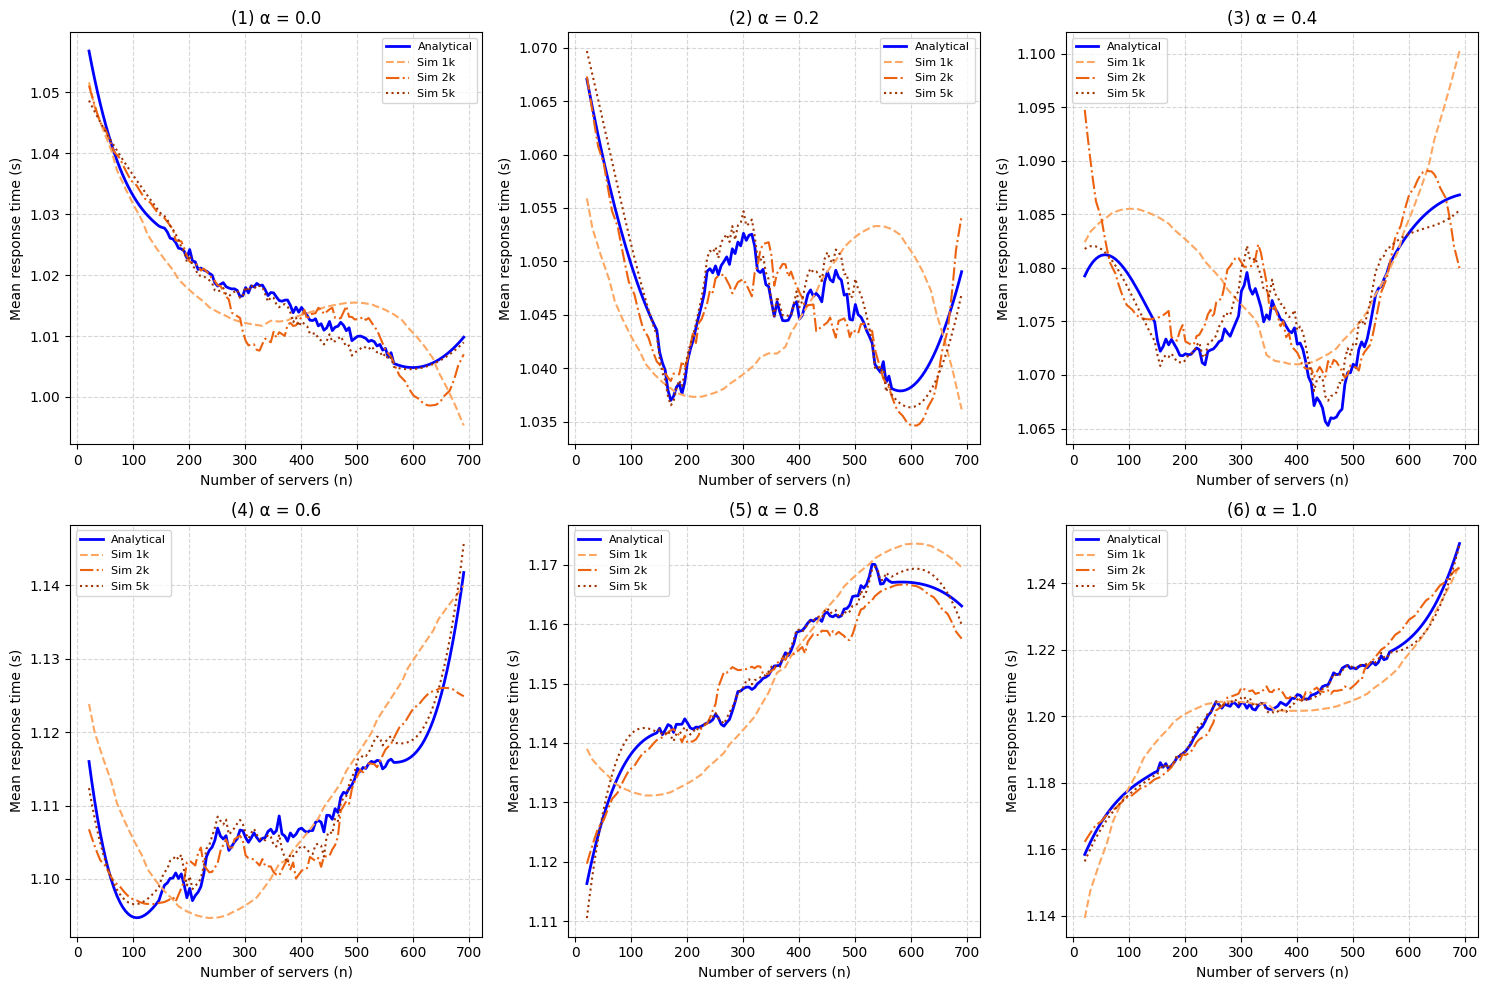

In [68]:
# Конфигурации симуляций
sim_configs = [
    {'replications': 5, 'requests': 1000, 'warmup': 250, 'max_points': 50, 'label': 'Sim 1k'},
    {'replications': 5, 'requests': 2000, 'warmup': 250, 'max_points': 110, 'label': 'Sim 2k'},
    {'replications': 5, 'requests': 4000, 'warmup': 500, 'max_points': 350, 'label': 'Sim 5k'}
]


fig, metrics_emp, metrics_anal = plot_analytical_vs_simulations(
    experiment_data_df=experiment_data_df,
    state_df=state_df,
    mu_n_alpha_i=mu_d,
    fallback_mu_n_alpha=fallback_mu_poly,
    lam=0.3,
    alphas=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    n_range=range(21, 694, 5),
    sim_configs=sim_configs,
    cache_path='sim_cache',
    n_workers=8,
    compute_ci=True,
    ci_level=0.95,
    save_path='analytical_vs_simulations.png'
)
plt.show()